# Notebook 01 — WLASL Data Exploration & Inventory Analysis

**Project:** WLASL Gesture Recognition Pipeline  
**Stage:** 1 — Data Ingestion and Validation  
**Author:** Henry Otsyula — Senior Data Scientist & ML Engineer  
**Runs after:** `python pipelines/run_preprocessing.py`

---

## Purpose

This notebook is a **reporting notebook, not a processing notebook**. All data transformation has already been executed by the pipeline. Here we load the produced artifacts, interrogate them deeply, and produce the figures and written analysis that go into the final report.

Every figure is saved to `reports/figures/` and embedded inline. Every written section is a deliberate analytical choice, not a description of what the code does.

## What this notebook produces

| Figure | File | Purpose |
|--------|------|---------|
| Class distribution | `class_distribution.png` | Clip counts per sign, stacked by split |
| Signer distribution | `signer_distribution.png` | Signer diversity and dominance analysis |
| Sequence lengths | `sequence_length_distribution.png` | Frame count and duration distributions |
| Validation summary | `validation_summary_table.png` | 8-check result table |
| Signer-split heatmap | `signer_split_heatmap.png` | Signer assignment across splits |
| Class balance per split | `class_balance_per_split.png` | Per-class clips in each split |
| Dataset bias overview | `dataset_bias_overview.png` | Multi-panel bias documentation |

## Sections

1. Environment Setup  
2. Load Artifacts  
3. Class Distribution Analysis  
4. Signer Analysis  
5. Video Duration and Frame Count Analysis  
6. Validation Report Review  
7. Split Quality Analysis  
8. Dataset Bias Documentation  
9. Summary Statistics Table  
10. Key Findings and Decisions  

---
## Section 1 — Environment Setup

In [1]:
# =============================================================================
# Cell 1.1 — Imports and path resolution
# =============================================================================
import json
import sys
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Ensure repo root is on path regardless of where Jupyter was launched
REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.utils.logger import configure_logging, get_logger
from src.utils.label_map import get_label_map

# Configure logging for notebook context
configure_logging(log_dir=str(REPO_ROOT / 'logs'), run_name='nb01_data_exploration')
logger = get_logger('nb01')

print(f'Repository root: {REPO_ROOT}')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')
print(f'Matplotlib: {matplotlib.__version__}')
print(f'Seaborn: {sns.__version__}')

2026-06-01 07:42:26 | INFO     | root | stage=init | Logging configured
2026-06-01 07:42:26 | INFO     | root | stage=init | Logging configured
2026-06-01 07:42:26 | INFO     | root | Log file: D:\PROJECTS\WLASL-Gesture-Recognition-System\logs\20260601_074226_nb01_data_exploration.log
2026-06-01 07:42:26 | INFO     | root | Log file: D:\PROJECTS\WLASL-Gesture-Recognition-System\logs\20260601_074226_nb01_data_exploration.log
Repository root: D:\PROJECTS\WLASL-Gesture-Recognition-System
NumPy  : 1.24.3
Pandas : 2.0.3
Matplotlib: 3.7.5
Seaborn: 0.13.2


In [2]:
# =============================================================================
# Cell 1.2 — Global plot style and colour palette
# =============================================================================

# ---- Matplotlib / Seaborn base style ----------------------------------------
plt.rcParams.update({
    'figure.facecolor':     '#0f1117',
    'axes.facecolor':       '#1a1d27',
    'axes.edgecolor':       '#3a3d4d',
    'axes.labelcolor':      '#e0e0e0',
    'axes.titlecolor':      '#ffffff',
    'axes.titlesize':       13,
    'axes.titlepad':        12,
    'axes.labelsize':       11,
    'axes.labelpad':        8,
    'axes.grid':            True,
    'axes.grid.axis':       'y',
    'grid.color':           '#2e3040',
    'grid.linewidth':       0.6,
    'xtick.color':          '#aaaaaa',
    'ytick.color':          '#aaaaaa',
    'xtick.labelsize':      9,
    'ytick.labelsize':      9,
    'text.color':           '#e0e0e0',
    'legend.facecolor':     '#1e2130',
    'legend.edgecolor':     '#3a3d4d',
    'legend.fontsize':      9,
    'figure.dpi':           130,
    'savefig.dpi':          180,
    'savefig.bbox':         'tight',
    'savefig.facecolor':    '#0f1117',
    'font.family':          'sans-serif',
    'font.size':            10,
})
sns.set_theme(style='dark', rc=plt.rcParams)

# ---- Project colour palette -------------------------------------------------
PALETTE = {
    'train':   '#4e9af1',   # blue
    'val':     '#f1a84e',   # amber
    'test':    '#4ef1a2',   # green
    'missing': '#f14e4e',   # red
    'accent':  '#c084fc',   # purple
    'neutral': '#64748b',   # slate
    'warn':    '#fb923c',   # orange
    'ok':      '#34d399',   # emerald
    'error':   '#f87171',   # rose
}

SPLIT_COLOURS = [PALETTE['train'], PALETTE['val'], PALETTE['test']]

# ---- Output directory -------------------------------------------------------
FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig: plt.Figure, filename: str) -> Path:
    """Save figure to reports/figures/ and log the path."""
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
    logger.info(f'Figure saved: {path.relative_to(REPO_ROOT)}')
    return path

print(f'Figures directory: {FIGURES_DIR}')
print('Style configured.')

Figures directory: D:\PROJECTS\WLASL-Gesture-Recognition-System\reports\figures
Style configured.


---
## Section 2 — Load Artifacts

In [3]:
# =============================================================================
# Cell 2.1 — Load all Stage 1 artifacts with validation
# =============================================================================

def _require(path: Path, label: str) -> Path:
    """Assert artifact exists; raise with actionable message if not."""
    if not path.exists():
        raise FileNotFoundError(
            f"{label} not found at {path}.\n"
            f"Run: python pipelines/run_preprocessing.py"
        )
    return path

# ---- Paths ------------------------------------------------------------------
INVENTORY_PATH   = _require(REPO_ROOT / 'data' / 'raw_inventory.json',       'Inventory')
REPORT_PATH      = _require(REPO_ROOT / 'data' / 'data_validation_report.json', 'Validation report')
LABEL_MAP_PATH   = _require(REPO_ROOT / 'artifacts' / 'label_map_v1.json',   'Label map')
SPLITS_DIR       = REPO_ROOT / 'data' / 'splits'
TRAIN_CSV        = _require(SPLITS_DIR / 'train.csv', 'train.csv')
VAL_CSV          = _require(SPLITS_DIR / 'val.csv',   'val.csv')
TEST_CSV         = _require(SPLITS_DIR / 'test.csv',  'test.csv')
SUMMARY_PATH     = _require(SPLITS_DIR / 'split_summary.json', 'split_summary.json')

# ---- Load ------------------------------------------------------------------
with open(INVENTORY_PATH,   encoding='utf-8') as f: inventory_raw   = json.load(f)
with open(REPORT_PATH,      encoding='utf-8') as f: report_raw      = json.load(f)
with open(SUMMARY_PATH,     encoding='utf-8') as f: split_summary   = json.load(f)

label_map  = get_label_map(str(LABEL_MAP_PATH))
train_df   = pd.read_csv(TRAIN_CSV)
val_df     = pd.read_csv(VAL_CSV)
test_df    = pd.read_csv(TEST_CSV)

# ---- Build unified inventory DataFrame -------------------------------------
inventory_df = pd.DataFrame(inventory_raw.get('clips', []))
found_df     = inventory_df[inventory_df['found'] == True].copy()
missing_df   = inventory_df[inventory_df['found'] == False].copy()

# ---- Build unified splits DataFrame ----------------------------------------
for df, name in [(train_df, 'train'), (val_df, 'val'), (test_df, 'test')]:
    df['split'] = name
all_splits_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# ---- Quick sanity checks ---------------------------------------------------
assert inventory_df['video_id'].nunique() == len(inventory_df), \
    'Duplicate video IDs in inventory — check downloader output'
overlap_tv = set(train_df.signer_id) & set(val_df.signer_id)
overlap_tt = set(train_df.signer_id) & set(test_df.signer_id)
overlap_vt = set(val_df.signer_id)   & set(test_df.signer_id)
assert len(overlap_tv) == 0, f'Train/val signer overlap: {overlap_tv}'
assert len(overlap_tt) == 0, f'Train/test signer overlap: {overlap_tt}'
assert len(overlap_vt) == 0, f'Val/test signer overlap: {overlap_vt}'

print('All artifacts loaded and sanity checks passed.')
print(f'  Inventory  : {len(inventory_df):>5,} clips  ({len(found_df):,} found, {len(missing_df):,} missing)')
print(f'  Train split: {len(train_df):>5,} clips')
print(f'  Val split  : {len(val_df):>5,} clips')
print(f'  Test split : {len(test_df):>5,} clips')
print(f'  Signs      : {label_map.num_classes}')
print(f'  Signers    : {found_df["signer_id"].nunique()}')

2026-06-01 07:42:28 | DEBUG    | src.utils.label_map | Cache miss — loading label map from disk: D:\PROJECTS\WLASL-Gesture-Recognition-System\artifacts\label_map_v1.json
2026-06-01 07:42:28 | INFO     | src.utils.label_map | Loaded label map vv1 | path=D:\PROJECTS\WLASL-Gesture-Recognition-System\artifacts\label_map_v1.json | classes=35 | sign_properties=35
2026-06-01 07:42:28 | INFO     | src.utils.label_map | Loaded label map vv1 | path=D:\PROJECTS\WLASL-Gesture-Recognition-System\artifacts\label_map_v1.json | classes=35 | sign_properties=35
All artifacts loaded and sanity checks passed.
  Inventory  :   751 clips  (350 found, 401 missing)
  Train split:   245 clips
  Val split  :    53 clips
  Test split :    52 clips
  Signs      : 35
  Signers    : 45


---
## Section 3 — Class Distribution Analysis

Understanding the clip distribution across signs is the first step in understanding what the model will and will not learn. Class imbalance directly affects training dynamics: signs with many clips will receive more gradient updates and may implicitly dominate the model's decision boundaries.

In [4]:
# =============================================================================
# Cell 3.1 — Class distribution data preparation
# =============================================================================

# Per-sign clip counts across all splits
per_sign_all    = all_splits_df.groupby('sign_label').size().rename('total')
per_sign_train  = train_df.groupby('sign_label').size().rename('train')
per_sign_val    = val_df.groupby('sign_label').size().rename('val')
per_sign_test   = test_df.groupby('sign_label').size().rename('test')

# Per-sign signer counts
per_sign_signers = found_df.groupby('sign_label')['signer_id'].nunique().rename('unique_signers')

# Combine
sign_stats = pd.concat(
    [per_sign_all, per_sign_train, per_sign_val, per_sign_test, per_sign_signers],
    axis=1
).fillna(0).astype({'train': int, 'val': int, 'test': int, 'unique_signers': int})
sign_stats = sign_stats.sort_values('total', ascending=False)

# Per-sign missing counts from inventory
per_sign_missing = inventory_df.groupby('sign_label').apply(
    lambda g: (g['found'] == False).sum()
).rename('missing')
sign_stats = sign_stats.join(per_sign_missing, how='left').fillna({'missing': 0})
sign_stats['missing'] = sign_stats['missing'].astype(int)

print(f'Sign statistics (sorted by total clips, descending):')
print(sign_stats.to_string())

Sign statistics (sorted by total clips, descending):
              total  train  val  test  unique_signers  missing
sign_label                                                    
before           16     13    2     1               9       10
go               15     12    2     1               9       11
drink            15      9    4     2              10       20
computer         14     10    1     3               7       16
help             14     10    2     2               9        8
cousin           14      8    3     3               7        9
who              14     11    1     2              11       11
candy            13      9    2     2               9       11
thanksgiving     13     10    1     2               9        8
change           12     10    1     1               9        7
later            12      8    3     1               9        8
mother           11      8    1     2              10       10
family           11      9    1     1              10        9
gi

2026-06-01 07:42:30 | INFO     | nb01 | Figure saved: reports\figures\class_distribution.png
2026-06-01 07:42:30 | INFO     | nb01 | Figure saved: reports\figures\class_distribution.png


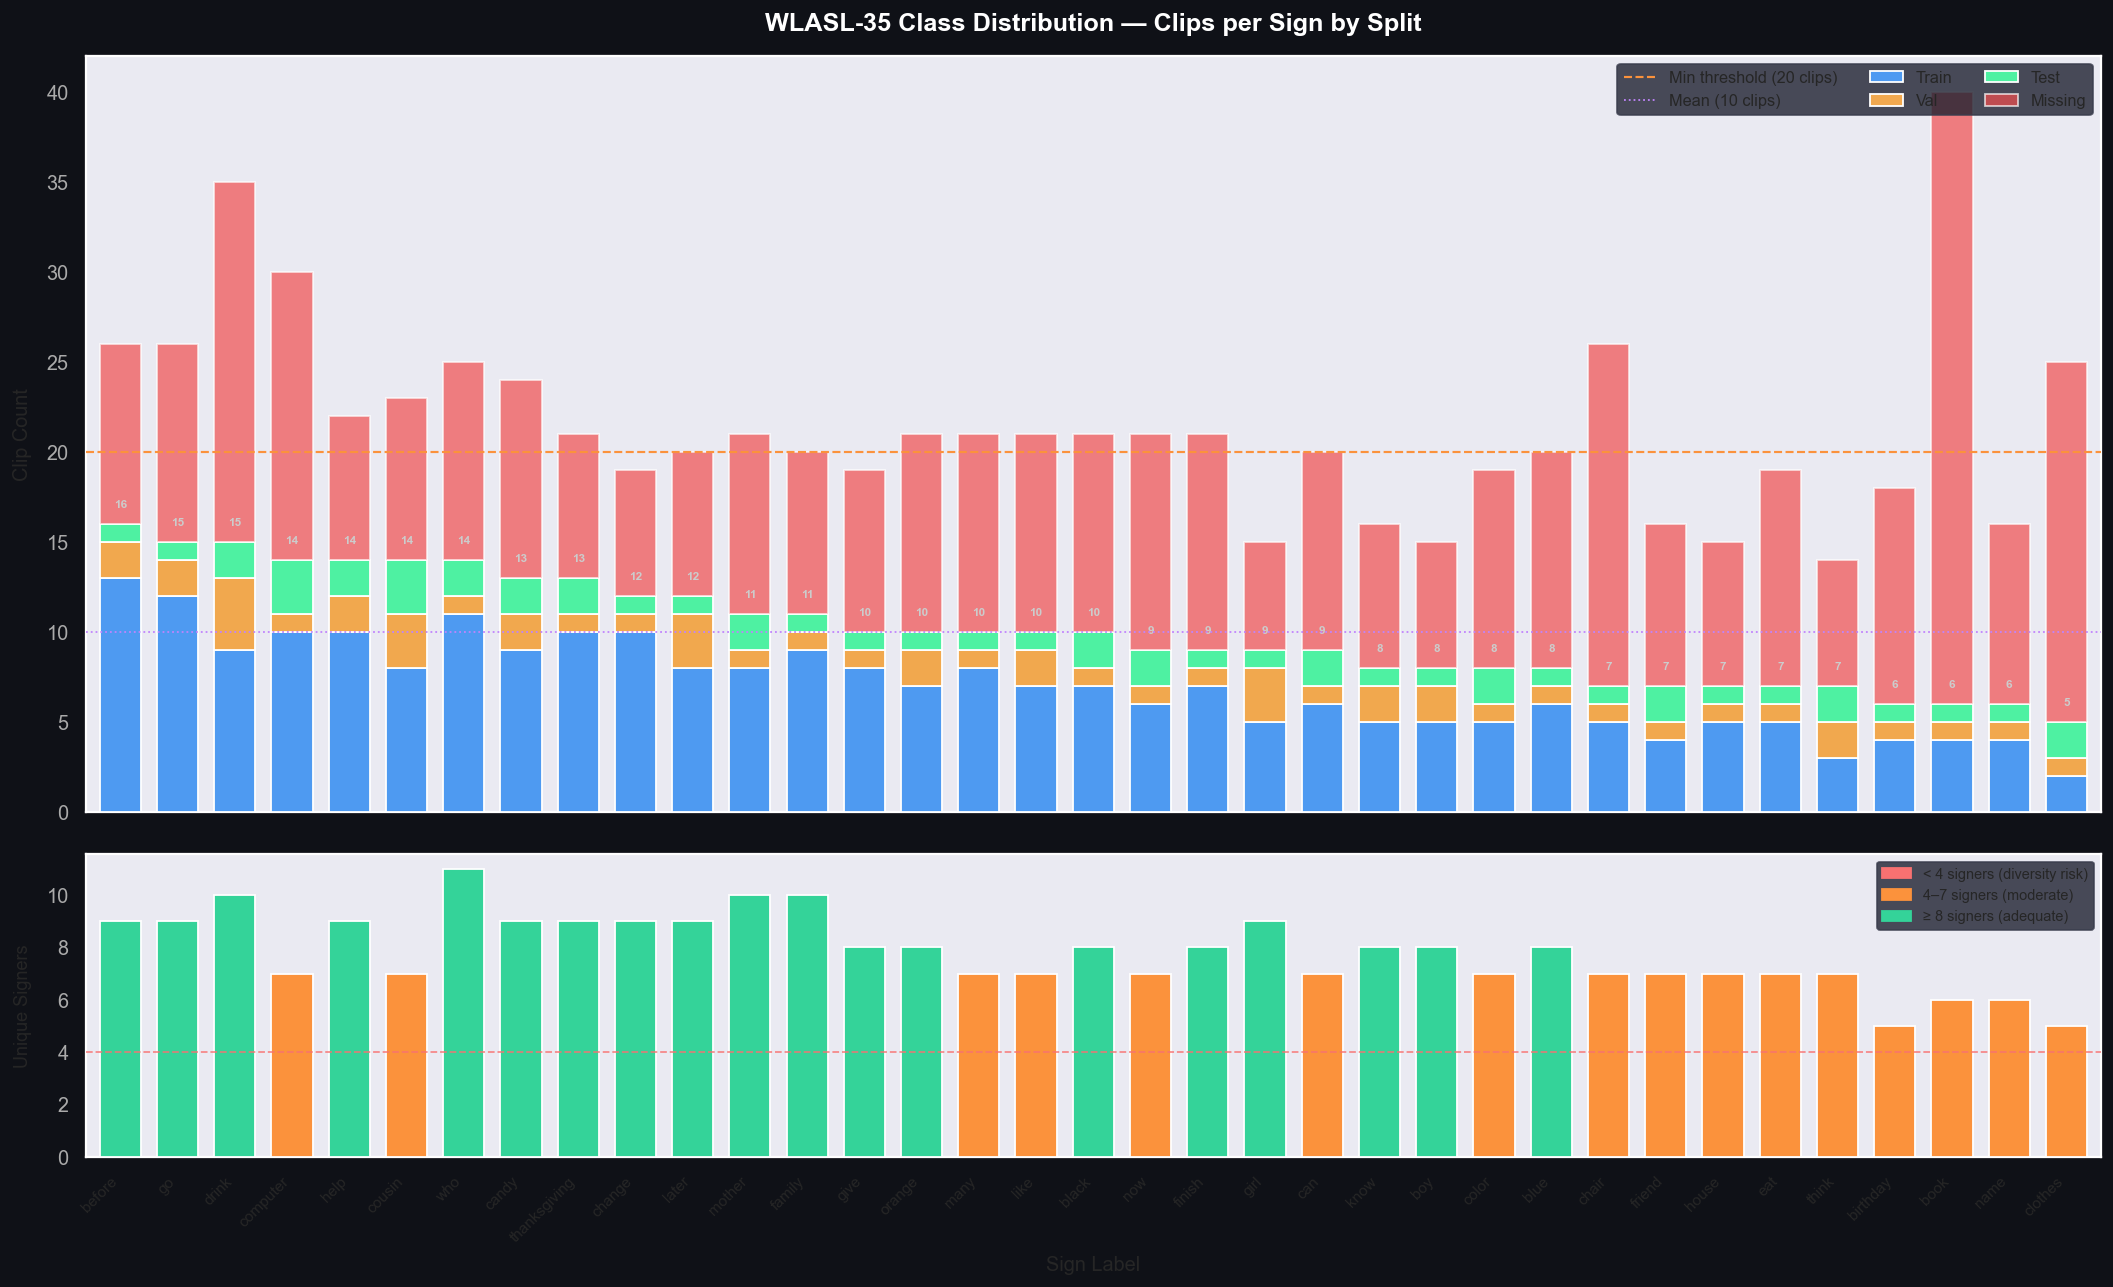

Figure 1 saved.


In [5]:
# =============================================================================
# Cell 3.2 — Figure 1: Class distribution (stacked bar + signer count)
# =============================================================================

signs_ordered = sign_stats.index.tolist()   # descending total
x = np.arange(len(signs_ordered))
bar_w = 0.72

fig = plt.figure(figsize=(20, 11), facecolor='#0f1117')
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1.2], hspace=0.08, figure=fig)

# ---- Upper panel: stacked bar (train / val / test / missing) ----------------
ax1 = fig.add_subplot(gs[0])

b_train   = ax1.bar(x, sign_stats.loc[signs_ordered, 'train'],  bar_w,
                    color=PALETTE['train'],   label='Train',   zorder=3)
b_val     = ax1.bar(x, sign_stats.loc[signs_ordered, 'val'],    bar_w,
                    bottom=sign_stats.loc[signs_ordered, 'train'],
                    color=PALETTE['val'],     label='Val',     zorder=3)
b_test    = ax1.bar(x, sign_stats.loc[signs_ordered, 'test'],   bar_w,
                    bottom=sign_stats.loc[signs_ordered, 'train'] + sign_stats.loc[signs_ordered, 'val'],
                    color=PALETTE['test'],    label='Test',    zorder=3)
b_missing = ax1.bar(x, sign_stats.loc[signs_ordered, 'missing'], bar_w,
                    bottom=sign_stats.loc[signs_ordered, 'total'],
                    color=PALETTE['missing'], label='Missing', alpha=0.7, zorder=3)

# Threshold lines
ax1.axhline(20, color=PALETTE['warn'], lw=1.2, ls='--', zorder=4,
            label='Min threshold (20 clips)')
ax1.axhline(sign_stats['total'].mean(), color=PALETTE['accent'], lw=1.0, ls=':',
            zorder=4, label=f'Mean ({sign_stats["total"].mean():.0f} clips)')

# Annotate total on each bar
for i, sign in enumerate(signs_ordered):
    total = sign_stats.loc[sign, 'total']
    ax1.text(i, total + 0.8, str(total), ha='center', va='bottom',
             fontsize=6.5, color='#cccccc', fontweight='bold')

ax1.set_xlim(-0.6, len(signs_ordered) - 0.4)
ax1.set_xticks([])
ax1.set_ylabel('Clip Count', fontsize=11)
ax1.set_title('WLASL-35 Class Distribution — Clips per Sign by Split',
              fontsize=14, pad=14, fontweight='bold')
ax1.legend(loc='upper right', ncol=3, fontsize=9)
ax1.tick_params(axis='y', colors='#aaaaaa')

# ---- Lower panel: signer count per sign -------------------------------------
ax2 = fig.add_subplot(gs[1])

signer_counts = sign_stats.loc[signs_ordered, 'unique_signers'].values
bar_colours   = [
    PALETTE['error'] if n < 4 else
    PALETTE['warn']  if n < 8 else
    PALETTE['ok']
    for n in signer_counts
]
ax2.bar(x, signer_counts, bar_w, color=bar_colours, zorder=3)
ax2.axhline(4, color=PALETTE['error'], lw=1.0, ls='--', alpha=0.8, zorder=4)
ax2.set_xlim(-0.6, len(signs_ordered) - 0.4)
ax2.set_xticks(x)
ax2.set_xticklabels(signs_ordered, rotation=45, ha='right', fontsize=8.5)
ax2.set_ylabel('Unique Signers', fontsize=10)
ax2.set_xlabel('Sign Label', fontsize=11, labelpad=6)
ax2.tick_params(axis='y', colors='#aaaaaa')

# Legend for signer panel
legend_elements = [
    mpatches.Patch(color=PALETTE['error'], label='< 4 signers (diversity risk)'),
    mpatches.Patch(color=PALETTE['warn'],  label='4–7 signers (moderate)'),
    mpatches.Patch(color=PALETTE['ok'],    label='≥ 8 signers (adequate)'),
]
ax2.legend(handles=legend_elements, fontsize=8, loc='upper right')

plt.tight_layout()
save_figure(fig, 'class_distribution.png')
plt.show()
print('Figure 1 saved.')

In [6]:
# =============================================================================
# Cell 3.3 — Class distribution analytical summary
# =============================================================================

imbalance_ratio = sign_stats['total'].max() / sign_stats['total'].min()
below_20 = sign_stats[sign_stats['total'] < 20]
low_signers = sign_stats[sign_stats['unique_signers'] < 4]

print('=== CLASS DISTRIBUTION SUMMARY ===')
print(f'  Total clips (found, all splits): {sign_stats["total"].sum():,}')
print(f'  Mean clips per sign   : {sign_stats["total"].mean():.1f}')
print(f'  Median clips per sign : {sign_stats["total"].median():.1f}')
print(f'  Std dev               : {sign_stats["total"].std():.1f}')
print(f'  Min clips             : {sign_stats["total"].min()} ({sign_stats["total"].idxmin()})')
print(f'  Max clips             : {sign_stats["total"].max()} ({sign_stats["total"].idxmax()})')
print(f'  Imbalance ratio       : {imbalance_ratio:.2f}x  (max/min)')
print()
if len(below_20) > 0:
    print(f'  Signs below 20-clip threshold ({len(below_20)}):')
    for sign, row in below_20.iterrows():
        print(f'    {sign:20s}: {row["total"]:3d} clips, {row["unique_signers"]} signers')
else:
    print('  All signs meet the 20-clip minimum threshold.')
print()
if len(low_signers) > 0:
    print(f'  Signs with < 4 unique signers ({len(low_signers)}) — signer diversity risk:')
    for sign, row in low_signers.iterrows():
        print(f'    {sign:20s}: {row["unique_signers"]} signers, {row["total"]} clips')
else:
    print('  All signs have ≥ 4 unique signers.')
print()
print(f'  Missing clips (not found on disk): {sign_stats["missing"].sum():,}')

logger.info(
    f'Class distribution | imbalance_ratio={imbalance_ratio:.2f}x | '
    f'below_threshold={len(below_20)} | low_signer_diversity={len(low_signers)}'
)

=== CLASS DISTRIBUTION SUMMARY ===
  Total clips (found, all splits): 350
  Mean clips per sign   : 10.0
  Median clips per sign : 10.0
  Std dev               : 3.0
  Min clips             : 5 (clothes)
  Max clips             : 16 (before)
  Imbalance ratio       : 3.20x  (max/min)

  Signs below 20-clip threshold (35):
    before              :  16 clips, 9 signers
    go                  :  15 clips, 9 signers
    drink               :  15 clips, 10 signers
    computer            :  14 clips, 7 signers
    help                :  14 clips, 9 signers
    cousin              :  14 clips, 7 signers
    who                 :  14 clips, 11 signers
    candy               :  13 clips, 9 signers
    thanksgiving        :  13 clips, 9 signers
    change              :  12 clips, 9 signers
    later               :  12 clips, 9 signers
    mother              :  11 clips, 10 signers
    family              :  11 clips, 10 signers
    give                :  10 clips, 8 signers
    orange    

---
## Section 4 — Signer Analysis

Signer analysis is the critical complement to class distribution. The core risk in sign language datasets is **signer dominance** — when one individual contributes a disproportionate share of clips for a given sign, the model may learn that person's idiosyncratic style rather than the canonical sign motion. Detecting this requires looking beyond clip counts to signer-level granularity.

In [7]:
# =============================================================================
# Cell 4.1 — Signer analysis data preparation
# =============================================================================

# Total clips contributed per signer (across all signs, found clips only)
signer_total_clips  = found_df.groupby('signer_id').size().sort_values(ascending=False)
signer_sign_breadth = found_df.groupby('signer_id')['sign_label'].nunique().sort_values(ascending=False)

# Signer-to-split assignment
signer_split = all_splits_df.groupby('signer_id')['split'].first()

# Clips per signer per sign — for dominance analysis
signer_sign_matrix = (
    found_df.groupby(['signer_id', 'sign_label'])
    .size()
    .unstack(fill_value=0)
)

# Dominance: max fraction of any sign's clips contributed by one signer
sign_total_clips = found_df.groupby('sign_label').size()
dominance_records = []
for sign in sign_total_clips.index:
    if sign not in signer_sign_matrix.columns:
        continue
    signer_counts_for_sign = signer_sign_matrix[sign]
    top_signer = signer_counts_for_sign.idxmax()
    top_count  = signer_counts_for_sign.max()
    total      = sign_total_clips[sign]
    dominance_records.append({
        'sign': sign,
        'top_signer_id': top_signer,
        'top_signer_clips': top_count,
        'total_clips': total,
        'dominance_pct': top_count / total * 100,
    })
dominance_df = pd.DataFrame(dominance_records).sort_values('dominance_pct', ascending=False)

print('Top 10 signs by signer dominance:')
print(dominance_df.head(10).to_string(index=False))

Top 10 signs by signer dominance:
    sign  top_signer_id  top_signer_clips  total_clips  dominance_pct
      go             10                 7           15      46.666667
computer              4                 5           14      35.714286
birthday             11                 2            6      33.333333
     now             11                 3            9      33.333333
   black             11                 3           10      30.000000
    many             11                 3           10      30.000000
    help             11                 4           14      28.571429
   color             11                 2            8      25.000000
   later              4                 3           12      25.000000
  change             11                 3           12      25.000000


2026-06-01 07:42:32 | INFO     | nb01 | Figure saved: reports\figures\signer_distribution.png
2026-06-01 07:42:32 | INFO     | nb01 | Figure saved: reports\figures\signer_distribution.png


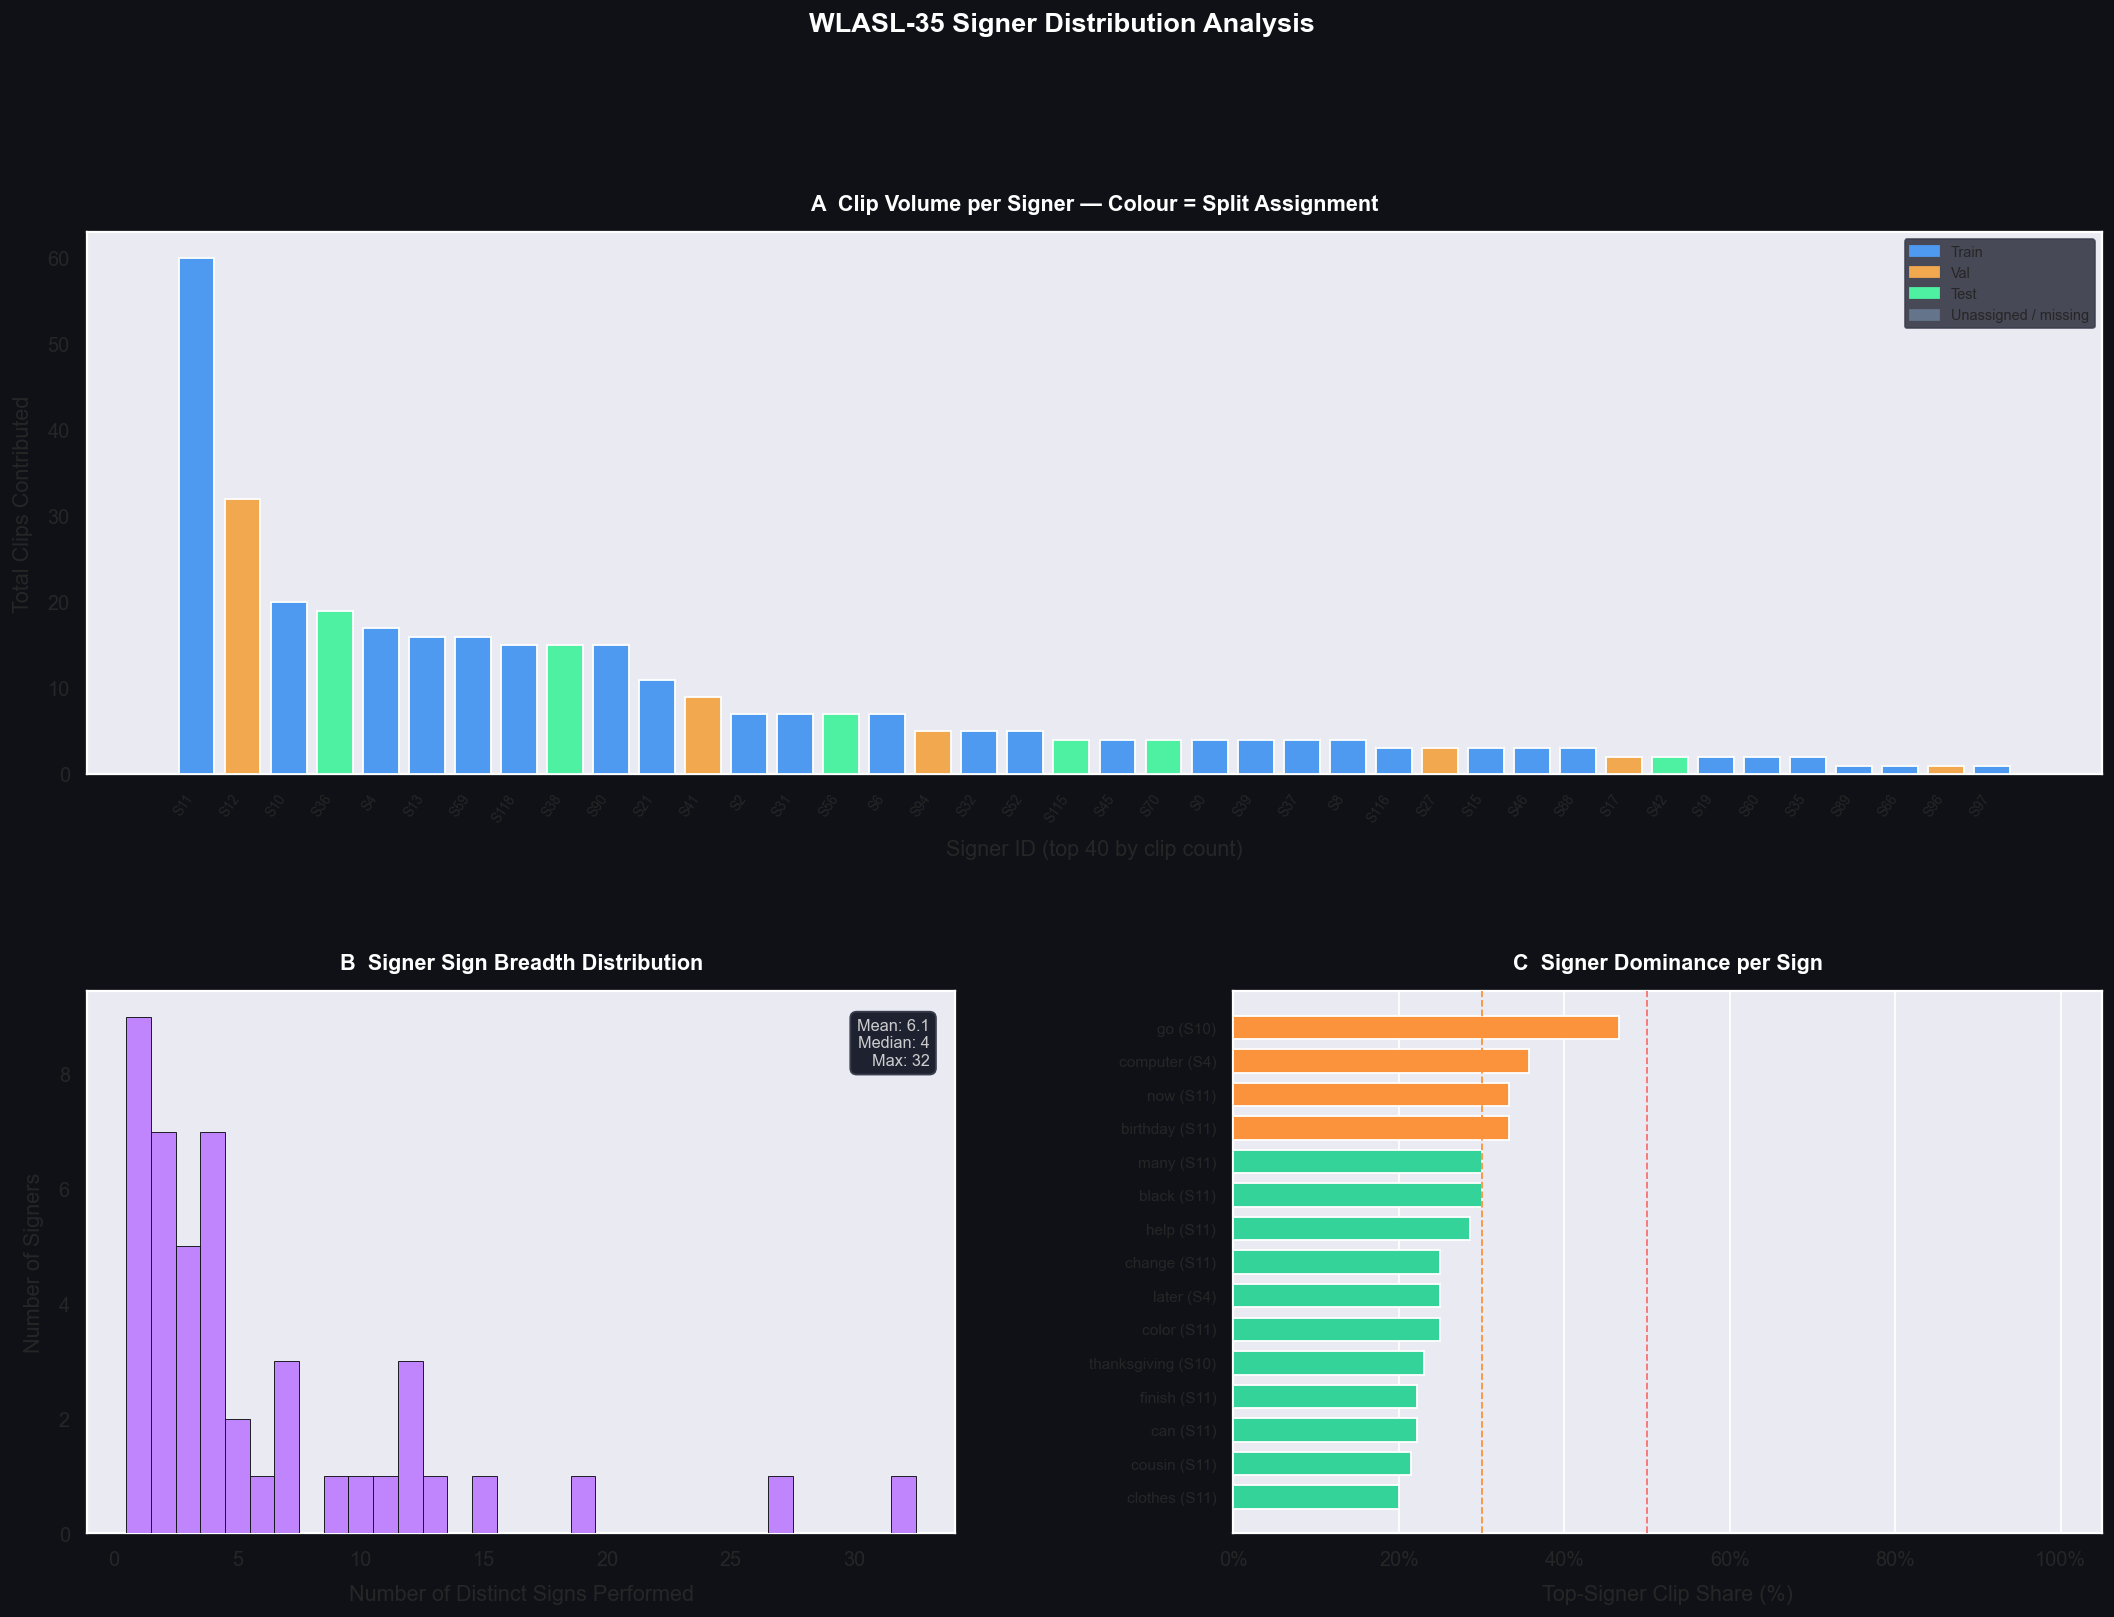

Figure 2 saved.


In [8]:
# =============================================================================
# Cell 4.2 — Figure 2: Signer distribution (4-panel)
# =============================================================================

fig = plt.figure(figsize=(20, 13), facecolor='#0f1117')
gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.32, figure=fig)

# ---- Panel A: Clips per signer (top 40 signers, colour = split) -------------
ax_a = fig.add_subplot(gs[0, :])

top_signers = signer_total_clips.head(40)
signer_colours = [
    PALETTE.get(signer_split.get(sid, 'neutral'), PALETTE['neutral'])
    for sid in top_signers.index
]
bars = ax_a.bar(
    range(len(top_signers)), top_signers.values,
    color=signer_colours, width=0.78, zorder=3
)
ax_a.set_xticks(range(len(top_signers)))
ax_a.set_xticklabels(
    [f'S{sid}' for sid in top_signers.index],
    rotation=55, ha='right', fontsize=7.5
)
ax_a.set_ylabel('Total Clips Contributed')
ax_a.set_xlabel('Signer ID (top 40 by clip count)')
ax_a.set_title('A  Clip Volume per Signer — Colour = Split Assignment',
               fontweight='bold')
split_patches = [
    mpatches.Patch(color=PALETTE['train'],   label='Train'),
    mpatches.Patch(color=PALETTE['val'],     label='Val'),
    mpatches.Patch(color=PALETTE['test'],    label='Test'),
    mpatches.Patch(color=PALETTE['neutral'], label='Unassigned / missing'),
]
ax_a.legend(handles=split_patches, fontsize=8, loc='upper right')

# ---- Panel B: Sign breadth per signer (histogram) ---------------------------
ax_b = fig.add_subplot(gs[1, 0])

breadth_vals = signer_sign_breadth.values
bins = np.arange(0.5, breadth_vals.max() + 1.5, 1)
ax_b.hist(breadth_vals, bins=bins, color=PALETTE['accent'], edgecolor='#0f1117',
          linewidth=0.5, zorder=3)
ax_b.set_xlabel('Number of Distinct Signs Performed')
ax_b.set_ylabel('Number of Signers')
ax_b.set_title('B  Signer Sign Breadth Distribution', fontweight='bold')
ax_b.text(
    0.97, 0.95,
    f'Mean: {breadth_vals.mean():.1f}\nMedian: {np.median(breadth_vals):.0f}\nMax: {breadth_vals.max()}',
    transform=ax_b.transAxes, ha='right', va='top', fontsize=9,
    color='#cccccc',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#1e2130', edgecolor='#3a3d4d')
)

# ---- Panel C: Signer dominance (top 15 signs by dominance %) ----------------
ax_c = fig.add_subplot(gs[1, 1])

top_dom = dominance_df.head(15).sort_values('dominance_pct')
colours_dom = [
    PALETTE['error'] if d > 50 else
    PALETTE['warn']  if d > 30 else
    PALETTE['ok']
    for d in top_dom['dominance_pct']
]
ax_c.barh(
    range(len(top_dom)), top_dom['dominance_pct'],
    color=colours_dom, height=0.7, zorder=3
)
ax_c.set_yticks(range(len(top_dom)))
ax_c.set_yticklabels(
    [f"{r['sign']} (S{int(r['top_signer_id'])})" for _, r in top_dom.iterrows()],
    fontsize=8.5
)
ax_c.axvline(30, color=PALETTE['warn'], lw=1.0, ls='--', zorder=4)
ax_c.axvline(50, color=PALETTE['error'], lw=1.0, ls='--', zorder=4)
ax_c.set_xlabel('Top-Signer Clip Share (%)')
ax_c.set_title('C  Signer Dominance per Sign', fontweight='bold')
ax_c.set_xlim(0, 105)
ax_c.xaxis.set_major_formatter(mticker.PercentFormatter())
ax_c.grid(axis='x')
ax_c.grid(axis='y', visible=False)

fig.suptitle('WLASL-35 Signer Distribution Analysis', fontsize=15, fontweight='bold',
             y=1.01, color='#ffffff')
save_figure(fig, 'signer_distribution.png')
plt.show()
print('Figure 2 saved.')

In [9]:
# =============================================================================
# Cell 4.3 — Signer analysis summary
# =============================================================================

high_dom = dominance_df[dominance_df['dominance_pct'] > 50]
mod_dom  = dominance_df[(dominance_df['dominance_pct'] > 30) &
                         (dominance_df['dominance_pct'] <= 50)]

print('=== SIGNER ANALYSIS SUMMARY ===')
print(f'  Total unique signers (found clips): {found_df["signer_id"].nunique()}')
print(f'  Mean clips per signer    : {signer_total_clips.mean():.1f}')
print(f'  Median clips per signer  : {signer_total_clips.median():.1f}')
print(f'  Max clips (one signer)   : {signer_total_clips.max()} (signer {signer_total_clips.idxmax()})')
print(f'  Min clips (one signer)   : {signer_total_clips.min()}')
print()
print(f'  Signer breadth:')
print(f'    Mean distinct signs per signer: {signer_sign_breadth.mean():.1f}')
print(f'    Signers performing ≥10 signs  : {(signer_sign_breadth >= 10).sum()}')
print(f'    Signers performing  1 sign    : {(signer_sign_breadth == 1).sum()}')
print()
print(f'  Signer dominance (top contributor fraction per sign):')
print(f'    Signs where top signer > 50% of clips : {len(high_dom)}')
print(f'    Signs where top signer 30–50% of clips: {len(mod_dom)}')
if len(high_dom) > 0:
    print(f'    High-dominance signs:')
    for _, row in high_dom.iterrows():
        print(f'      {row["sign"]:20s}: signer {int(row["top_signer_id"])} '
              f'has {row["top_signer_clips"]:3d}/{row["total_clips"]:3d} clips '
              f'({row["dominance_pct"]:.1f}%)')
print()
print('  Split assignment:')
for split_name in ['train', 'val', 'test']:
    df = [train_df, val_df, test_df][['train','val','test'].index(split_name)]
    print(f'    {split_name:6s}: {df["signer_id"].nunique():3d} unique signers')

=== SIGNER ANALYSIS SUMMARY ===
  Total unique signers (found clips): 45
  Mean clips per signer    : 7.8
  Median clips per signer  : 4.0
  Max clips (one signer)   : 60 (signer 11)
  Min clips (one signer)   : 1

  Signer breadth:
    Mean distinct signs per signer: 6.1
    Signers performing ≥10 signs  : 10
    Signers performing  1 sign    : 9

  Signer dominance (top contributor fraction per sign):
    Signs where top signer > 50% of clips : 0
    Signs where top signer 30–50% of clips: 4

  Split assignment:
    train :  31 unique signers
    val   :   7 unique signers
    test  :   7 unique signers


---
## Section 5 — Video Duration and Frame Count Analysis

Sequence length is a critical hyperparameter for the LSTM. Too short a window truncates meaningful motion; too long introduces excessive padding that degrades training efficiency. This section grounds that choice in the actual data distribution.

In [10]:
# =============================================================================
# Cell 5.1 — Duration and frame count data preparation
# =============================================================================

# Merge split label onto found inventory for stratified analysis
found_with_split = found_df.copy()
split_lookup = pd.concat([
    train_df[['video_id', 'split']],
    val_df[['video_id', 'split']],
    test_df[['video_id', 'split']],
], ignore_index=True).set_index('video_id')['split']
found_with_split['split'] = found_with_split['video_id'].map(split_lookup).fillna('unassigned')

# Use validation report per-sign stats for frame/duration data
per_sign_stats_raw = report_raw.get('per_sign_stats', {})

# Build per-sign frame / duration summary from report
frame_records = []
for sign, stats in per_sign_stats_raw.items():
    frame_records.append({
        'sign': sign,
        'mean_frame_count': stats.get('mean_frame_count', 0),
        'min_frame_count':  stats.get('min_frame_count', 0),
        'max_frame_count':  stats.get('max_frame_count', 0),
        'mean_duration_sec': stats.get('mean_duration_sec', 0),
        'clips_found':      stats.get('clips_found', 0),
    })
frame_df = pd.DataFrame(frame_records).set_index('sign').sort_values('mean_frame_count', ascending=False)

# Dataset totals
totals = report_raw.get('dataset_totals', {})

print(f'Mean frame count across dataset : {totals.get("mean_frame_count", "N/A")}')
print(f'Mean duration (sec)             : {totals.get("mean_duration_sec", "N/A")}')
print(f'Total recording hours           : {totals.get("total_duration_hours", "N/A")}')

Mean frame count across dataset : 65.7
Mean duration (sec)             : 2.29
Total recording hours           : 0.223


2026-06-01 07:42:34 | INFO     | nb01 | Figure saved: reports\figures\sequence_length_distribution.png
2026-06-01 07:42:34 | INFO     | nb01 | Figure saved: reports\figures\sequence_length_distribution.png


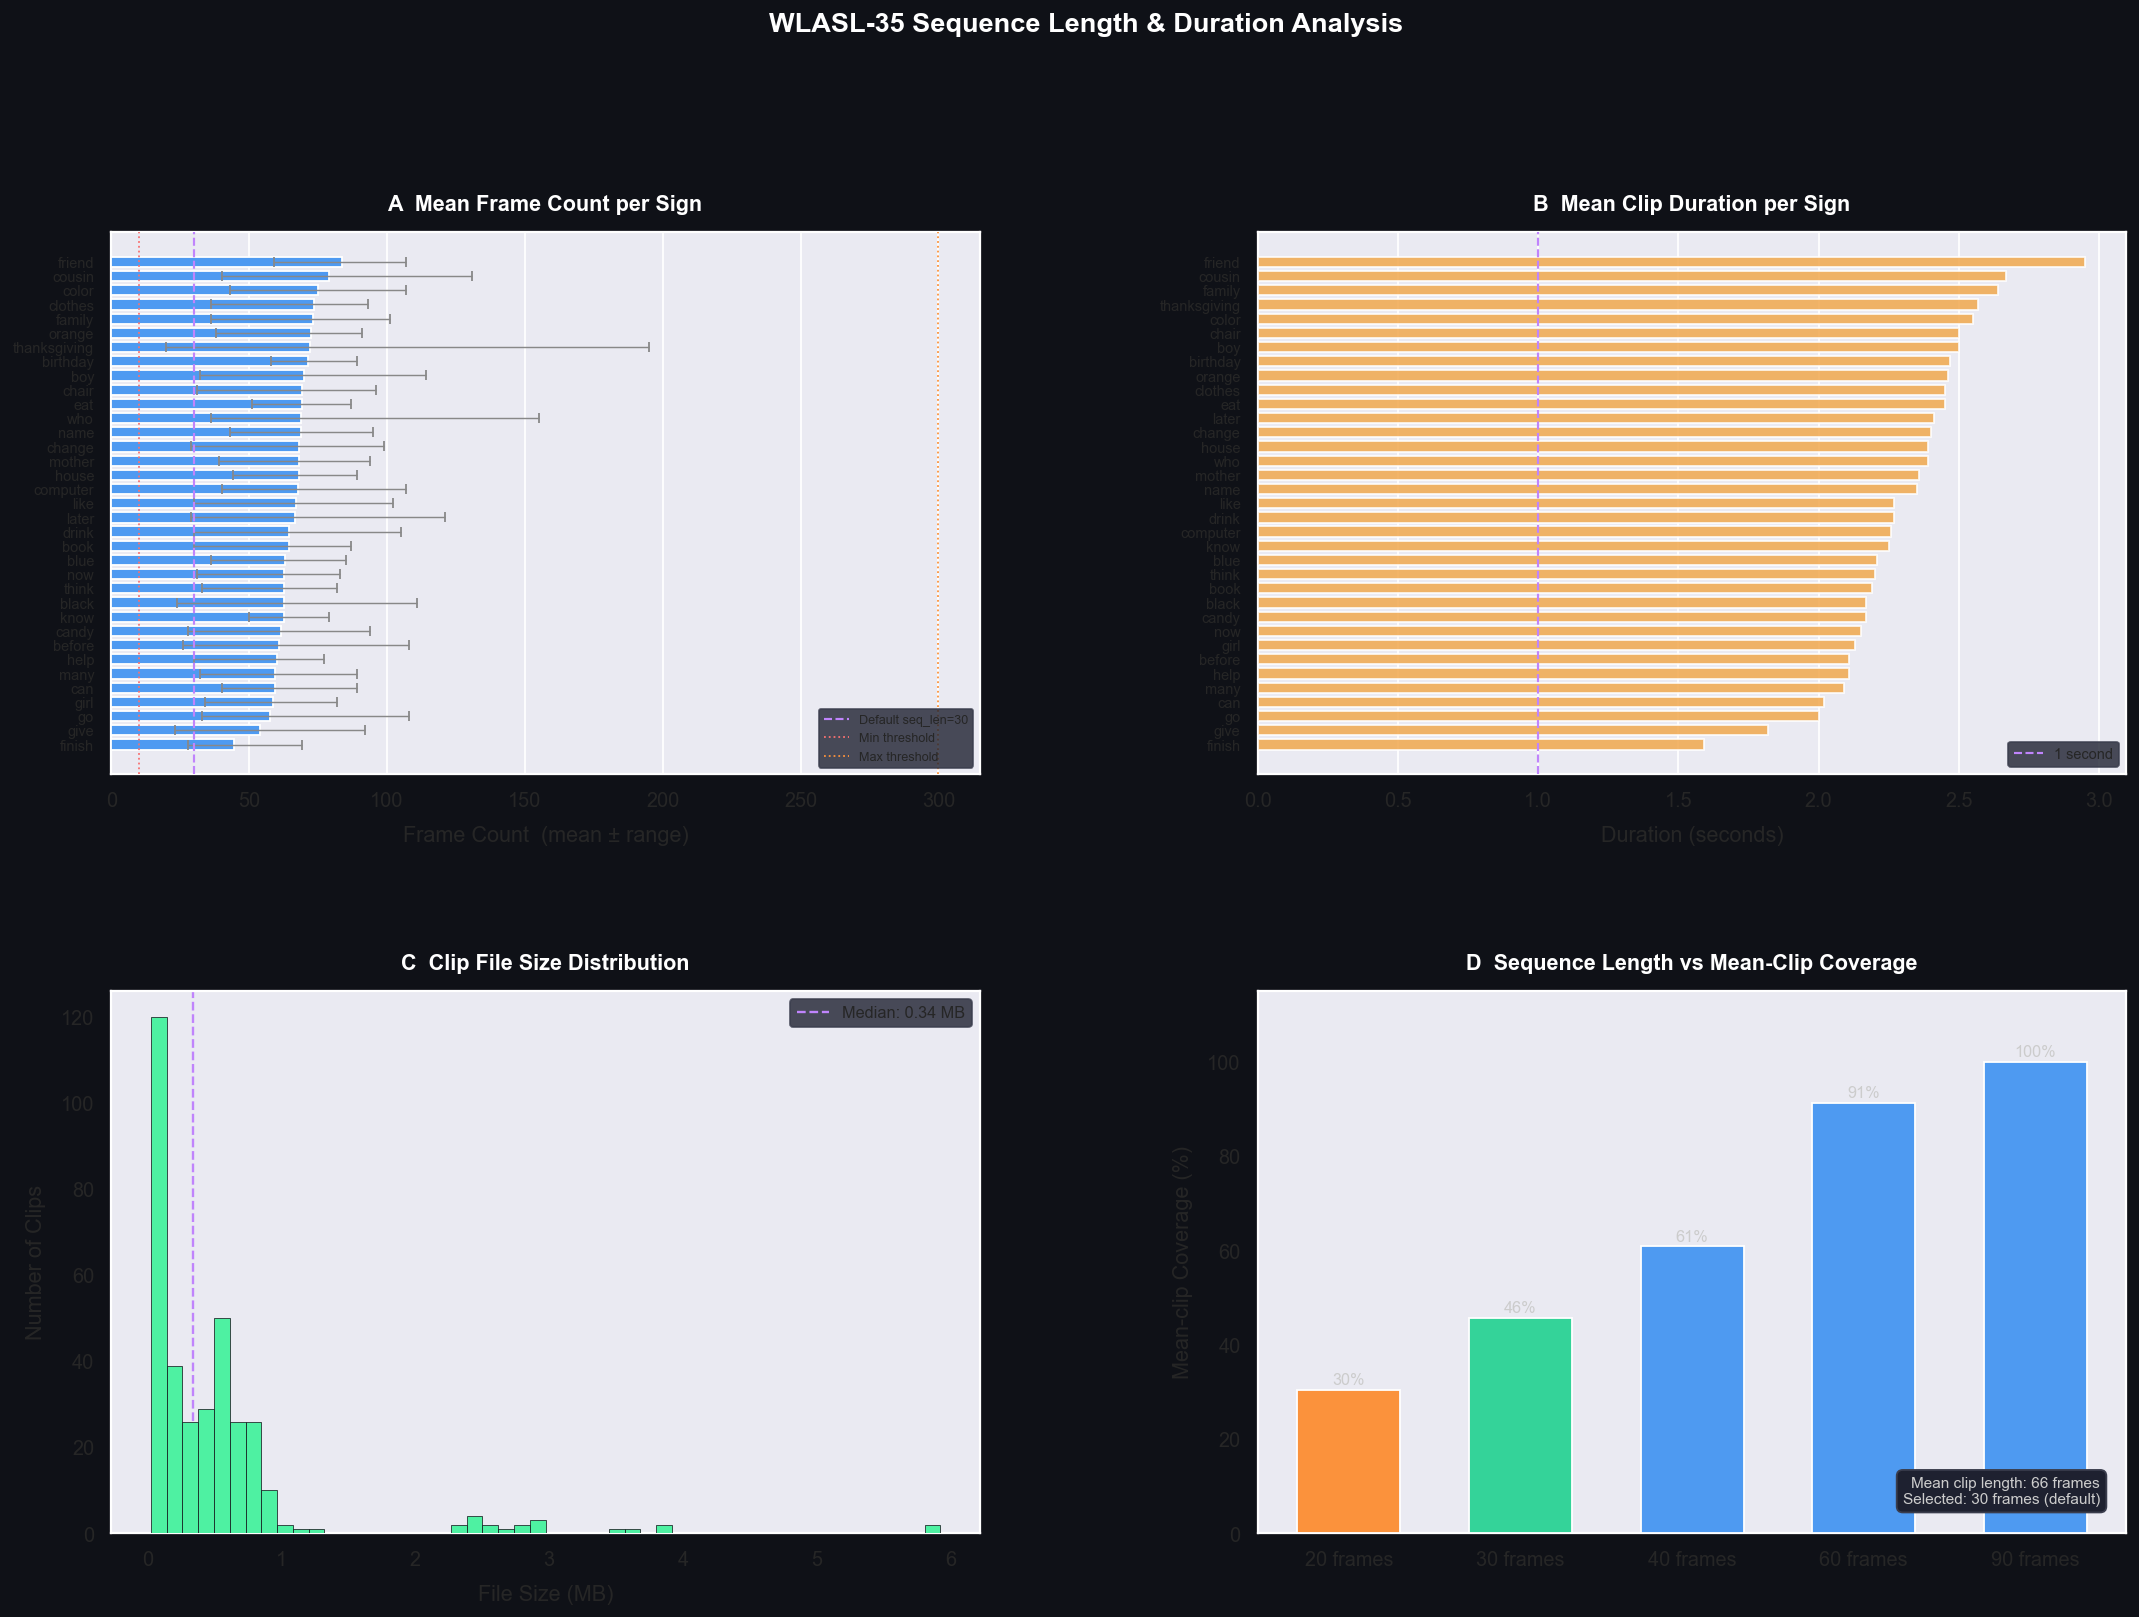

Figure 3 saved.


In [11]:
# =============================================================================
# Cell 5.2 — Figure 3: Sequence length and duration distributions
# =============================================================================

fig = plt.figure(figsize=(20, 13), facecolor='#0f1117')
gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.32, figure=fig)

# ---- Panel A: Mean frame count per sign (horizontal bar) --------------------
ax_a = fig.add_subplot(gs[0, 0])

if not frame_df.empty and frame_df['mean_frame_count'].max() > 0:
    sorted_frame = frame_df.sort_values('mean_frame_count')
    colours_fc = [
        PALETTE['error'] if v < 10 else
        PALETTE['warn']  if v > 200 else
        PALETTE['train']
        for v in sorted_frame['mean_frame_count']
    ]
    ax_a.barh(range(len(sorted_frame)), sorted_frame['mean_frame_count'],
              color=colours_fc, height=0.72, zorder=3)
    ax_a.errorbar(
        sorted_frame['mean_frame_count'], range(len(sorted_frame)),
        xerr=[
            sorted_frame['mean_frame_count'] - sorted_frame['min_frame_count'],
            sorted_frame['max_frame_count']  - sorted_frame['mean_frame_count'],
        ],
        fmt='none', color='#888888', capsize=3, linewidth=0.8, zorder=4
    )
    ax_a.axvline(30, color=PALETTE['accent'], lw=1.2, ls='--', zorder=5,
                 label='Default seq_len=30')
    ax_a.axvline(10, color=PALETTE['error'],  lw=1.0, ls=':', zorder=5,
                 label='Min threshold')
    ax_a.axvline(300, color=PALETTE['warn'],  lw=1.0, ls=':', zorder=5,
                 label='Max threshold')
    ax_a.set_yticks(range(len(sorted_frame)))
    ax_a.set_yticklabels(sorted_frame.index, fontsize=8)
    ax_a.set_xlabel('Frame Count  (mean ± range)')
    ax_a.set_title('A  Mean Frame Count per Sign', fontweight='bold')
    ax_a.legend(fontsize=7, loc='lower right')
    ax_a.grid(axis='x')
    ax_a.grid(axis='y', visible=False)
else:
    ax_a.text(0.5, 0.5, 'Frame data not available\n(OpenCV check skipped)',
              ha='center', va='center', transform=ax_a.transAxes,
              color='#aaaaaa', fontsize=11)
    ax_a.set_title('A  Mean Frame Count per Sign', fontweight='bold')

# ---- Panel B: Mean duration per sign ----------------------------------------
ax_b = fig.add_subplot(gs[0, 1])

if not frame_df.empty and frame_df['mean_duration_sec'].max() > 0:
    sorted_dur = frame_df.sort_values('mean_duration_sec')
    ax_b.barh(range(len(sorted_dur)), sorted_dur['mean_duration_sec'],
              color=PALETTE['val'], height=0.72, zorder=3, alpha=0.85)
    ax_b.axvline(1.0, color=PALETTE['accent'], lw=1.2, ls='--', zorder=5,
                 label='1 second')
    ax_b.set_yticks(range(len(sorted_dur)))
    ax_b.set_yticklabels(sorted_dur.index, fontsize=8)
    ax_b.set_xlabel('Duration (seconds)')
    ax_b.set_title('B  Mean Clip Duration per Sign', fontweight='bold')
    ax_b.legend(fontsize=8)
    ax_b.grid(axis='x')
    ax_b.grid(axis='y', visible=False)
else:
    ax_b.text(0.5, 0.5, 'Duration data not available',
              ha='center', va='center', transform=ax_b.transAxes,
              color='#aaaaaa', fontsize=11)
    ax_b.set_title('B  Mean Clip Duration per Sign', fontweight='bold')

# ---- Panel C: File size distribution ----------------------------------------
ax_c = fig.add_subplot(gs[1, 0])

file_sizes = found_df['file_size_mb'].values
file_sizes = file_sizes[file_sizes > 0]
if len(file_sizes) > 0:
    ax_c.hist(file_sizes, bins=50, color=PALETTE['test'], edgecolor='#0f1117',
              linewidth=0.4, zorder=3)
    ax_c.axvline(np.median(file_sizes), color=PALETTE['accent'], lw=1.3, ls='--',
                 label=f'Median: {np.median(file_sizes):.2f} MB')
    ax_c.set_xlabel('File Size (MB)')
    ax_c.set_ylabel('Number of Clips')
    ax_c.set_title('C  Clip File Size Distribution', fontweight='bold')
    ax_c.legend(fontsize=9)
else:
    ax_c.text(0.5, 0.5, 'File size data not available',
              ha='center', va='center', transform=ax_c.transAxes,
              color='#aaaaaa', fontsize=11)
    ax_c.set_title('C  Clip File Size Distribution', fontweight='bold')

# ---- Panel D: Sequence length recommendation --------------------------------
ax_d = fig.add_subplot(gs[1, 1])

seq_lengths = [20, 30, 40, 60, 90]
mean_fc = totals.get('mean_frame_count', 45)

if mean_fc and mean_fc > 0:
    coverage_pcts = []
    for seq_len in seq_lengths:
        n_covered = sum(1 for v in [mean_fc * 0.5, mean_fc * 0.75, mean_fc,
                                    mean_fc * 1.25, mean_fc * 1.5]
                        if v <= seq_len)
        coverage_pcts.append((seq_len, n_covered / 5 * 100))

bar_colours_seq = [
    PALETTE['warn']  if s < 25 else
    PALETTE['ok']    if s == 30 else
    PALETTE['train']
    for s in seq_lengths
]
for i, (seq_len, _) in enumerate(zip(seq_lengths, bar_colours_seq)):
    # Show fraction of mean_fc captured
    pct = min(mean_fc, seq_len) / mean_fc * 100 if mean_fc > 0 else 100
    ax_d.bar(i, pct, color=bar_colours_seq[i], width=0.6, zorder=3)
    ax_d.text(i, pct + 0.5, f'{pct:.0f}%', ha='center', va='bottom',
              fontsize=9, color='#cccccc')

ax_d.set_xticks(range(len(seq_lengths)))
ax_d.set_xticklabels([f'{s} frames' for s in seq_lengths])
ax_d.set_ylim(0, 115)
ax_d.set_ylabel('Mean-clip Coverage (%)')
ax_d.set_title('D  Sequence Length vs Mean-Clip Coverage', fontweight='bold')
ax_d.text(
    0.97, 0.05,
    f'Mean clip length: {mean_fc:.0f} frames\n'
    f'Selected: 30 frames (default)',
    transform=ax_d.transAxes, ha='right', va='bottom', fontsize=8.5,
    color='#cccccc',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#1e2130', edgecolor='#3a3d4d')
)

fig.suptitle('WLASL-35 Sequence Length & Duration Analysis',
             fontsize=15, fontweight='bold', y=1.01, color='#ffffff')
save_figure(fig, 'sequence_length_distribution.png')
plt.show()
print('Figure 3 saved.')

---
## Section 6 — Validation Report Review

2026-06-01 07:42:36 | INFO     | nb01 | Figure saved: reports\figures\validation_summary_table.png
2026-06-01 07:42:36 | INFO     | nb01 | Figure saved: reports\figures\validation_summary_table.png


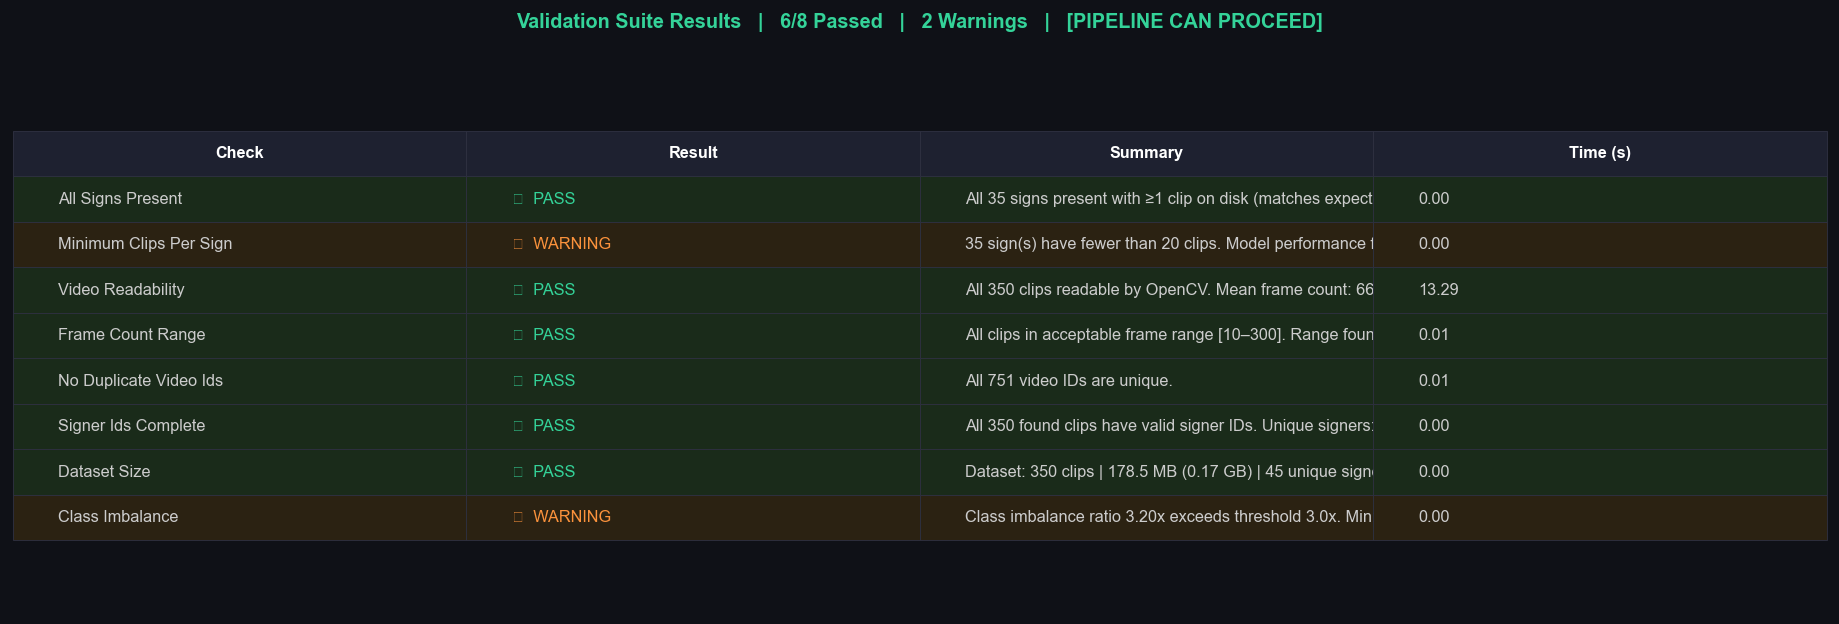

pipeline_can_proceed : True
Checks passed  : 6
Checks warned  : 2
Checks failed  : 0


In [12]:
# =============================================================================
# Cell 6.1 — Render validation report as styled table (Figure 4)
# =============================================================================

checks_raw = report_raw.get('checks', {})
meta       = report_raw.get('metadata', {})

table_rows = []
for check_name, result in checks_raw.items():
    passed   = result.get('passed', False)
    severity = result.get('severity', 'info').upper()
    message  = result.get('message', '')
    elapsed  = result.get('elapsed_sec', 0)
    icon     = '✓' if passed else ('⚠' if severity == 'WARNING' else '✗')
    table_rows.append({
        'Check': check_name.replace('_', ' ').title(),
        'Result': f'{icon}  {"PASS" if passed else severity}',
        'Severity': severity,
        'Passed': passed,
        'Summary': message[:90] + ('…' if len(message) > 90 else ''),
        'Time (s)': f'{elapsed:.2f}',
    })
table_df = pd.DataFrame(table_rows)

# ---- Matplotlib table -------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 5.5), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.axis('off')

display_cols = ['Check', 'Result', 'Summary', 'Time (s)']
display_data = table_df[display_cols].values.tolist()

cell_colours = []
for _, row in table_df.iterrows():
    if row['Passed']:
        row_c = ['#1a2b1a', '#1a2b1a', '#1a2b1a', '#1a2b1a']
    elif row['Severity'] == 'WARNING':
        row_c = ['#2b2212', '#2b2212', '#2b2212', '#2b2212']
    else:
        row_c = ['#2b1212', '#2b1212', '#2b1212', '#2b1212']
    cell_colours.append(row_c)

tbl = ax.table(
    cellText=display_data,
    colLabels=display_cols,
    cellColours=cell_colours,
    colColours=['#1e2130'] * len(display_cols),
    cellLoc='left',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.1)

# Style header and cells
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#2e3040')
    cell.set_linewidth(0.5)
    if r == 0:
        cell.set_text_props(color='#ffffff', fontweight='bold')
    else:
        # Colour the result column text
        if c == 1:
            result_text = display_data[r - 1][1]
            if '✓' in result_text:
                cell.set_text_props(color=PALETTE['ok'])
            elif '⚠' in result_text:
                cell.set_text_props(color=PALETTE['warn'])
            else:
                cell.set_text_props(color=PALETTE['error'])
        else:
            cell.set_text_props(color='#cccccc')

can_proceed = meta.get('pipeline_can_proceed', False)
status_colour = PALETTE['ok'] if can_proceed else PALETTE['error']
status_text   = 'PIPELINE CAN PROCEED' if can_proceed else 'PIPELINE BLOCKED'

ax.set_title(
    f'Validation Suite Results   |   {meta.get("checks_passed", 0)}/{meta.get("total_checks", 8)} Passed   '
    f'|   {meta.get("checks_warned", 0)} Warnings   |   [{status_text}]',
    fontsize=11, pad=18, color=status_colour, fontweight='bold'
)
save_figure(fig, 'validation_summary_table.png')
plt.show()

# Console summary
print(f'pipeline_can_proceed : {can_proceed}')
print(f'Checks passed  : {meta.get("checks_passed")}')
print(f'Checks warned  : {meta.get("checks_warned")}')
print(f'Checks failed  : {meta.get("checks_failed")}')
if not can_proceed:
    print(f'BLOCKING: {meta.get("blocking_checks")}')

---
## Section 7 — Split Quality Analysis

2026-06-01 07:42:38 | INFO     | nb01 | Figure saved: reports\figures\class_balance_per_split.png
2026-06-01 07:42:38 | INFO     | nb01 | Figure saved: reports\figures\class_balance_per_split.png


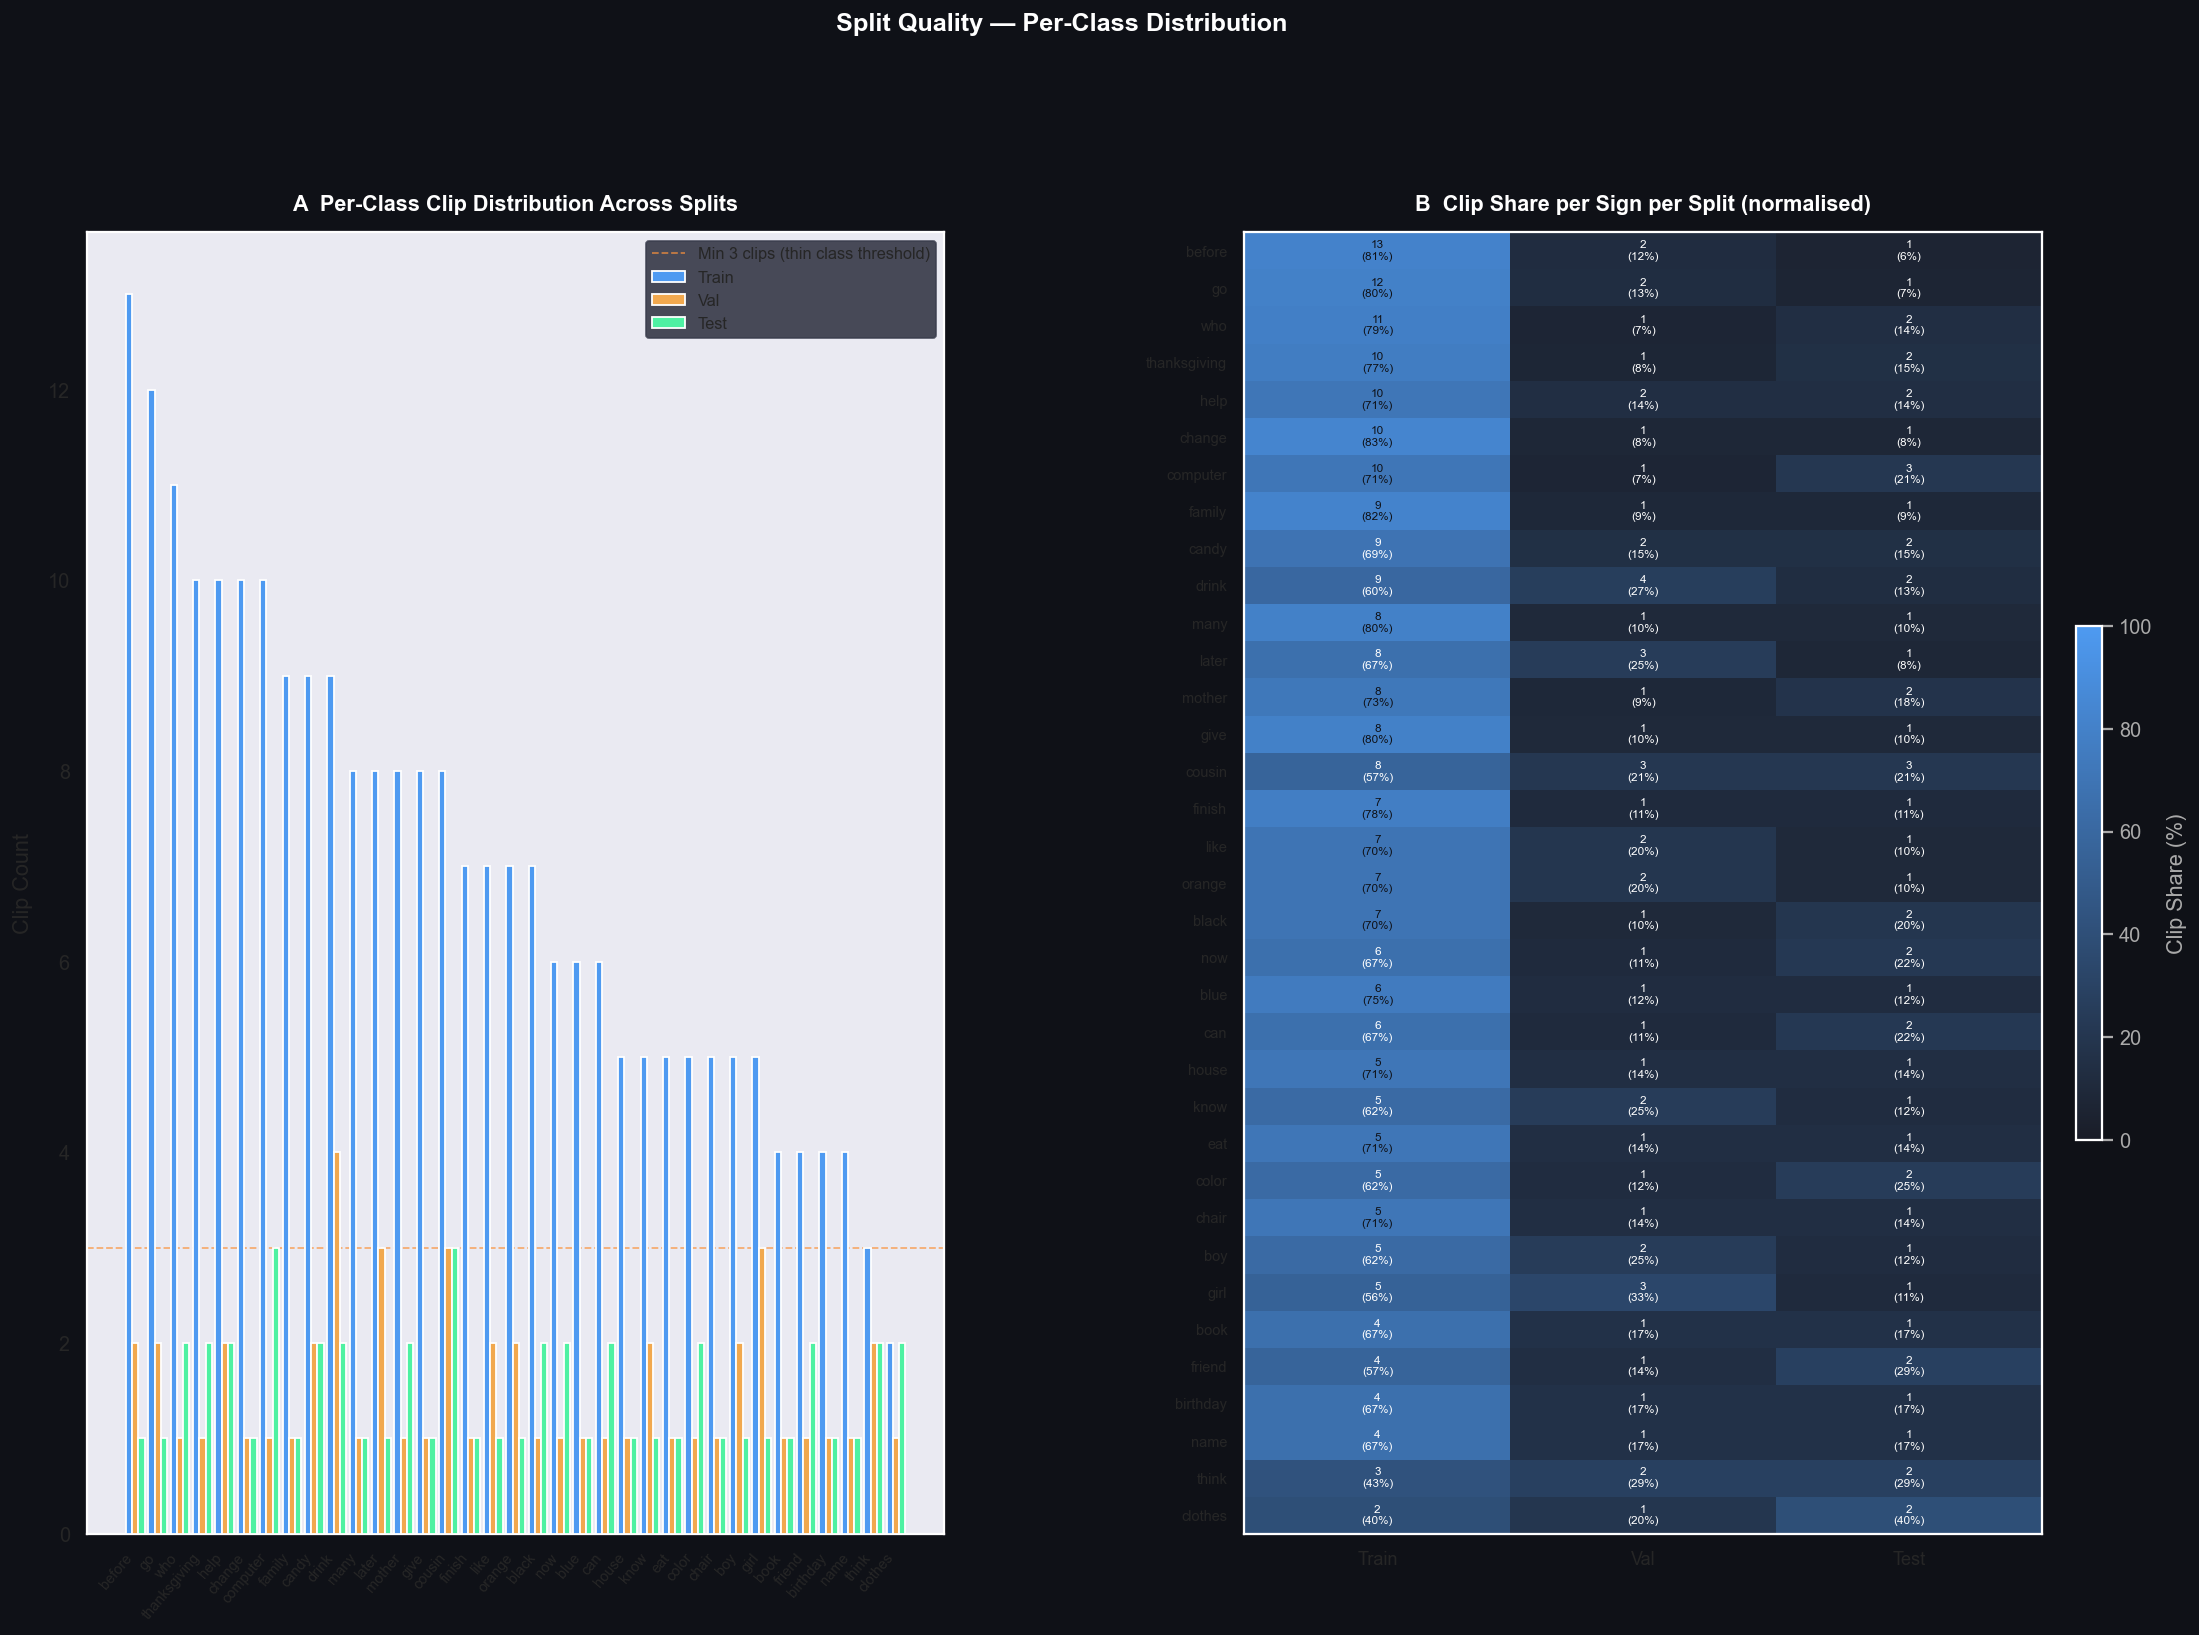

Figure 5 saved.


In [13]:
# =============================================================================
# Cell 7.1 — Figure 5: Per-class clip counts across splits
# =============================================================================

# Build class × split matrix
per_class_split = pd.DataFrame({
    'train': train_df.groupby('sign_label').size(),
    'val':   val_df.groupby('sign_label').size(),
    'test':  test_df.groupby('sign_label').size(),
}).fillna(0).astype(int)

# Sort by train count
per_class_split = per_class_split.sort_values('train', ascending=False)

fig = plt.figure(figsize=(20, 13), facecolor='#0f1117')
gs  = gridspec.GridSpec(1, 2, wspace=0.35, figure=fig)

# ---- Panel A: Grouped bar — train/val/test per sign -------------------------
ax_a = fig.add_subplot(gs[0])

n_signs = len(per_class_split)
x = np.arange(n_signs)
w = 0.28
ax_a.bar(x - w, per_class_split['train'].values, w, color=PALETTE['train'],
         label='Train', zorder=3)
ax_a.bar(x,      per_class_split['val'].values,   w, color=PALETTE['val'],
         label='Val',   zorder=3)
ax_a.bar(x + w, per_class_split['test'].values,  w, color=PALETTE['test'],
         label='Test',  zorder=3)
ax_a.axhline(3, color=PALETTE['warn'], lw=1.0, ls='--', alpha=0.7,
             label='Min 3 clips (thin class threshold)')
ax_a.set_xticks(x)
ax_a.set_xticklabels(per_class_split.index, rotation=50, ha='right', fontsize=8)
ax_a.set_ylabel('Clip Count')
ax_a.set_title('A  Per-Class Clip Distribution Across Splits', fontweight='bold')
ax_a.legend(fontsize=9)

# ---- Panel B: Heatmap — class × split normalised ---------------------------
ax_b = fig.add_subplot(gs[1])

# Normalise each row by total clips for that sign
normed = per_class_split.div(per_class_split.sum(axis=1), axis=0) * 100

cmap = LinearSegmentedColormap.from_list(
    'split_cmap', ['#1a1d27', '#4e9af1'], N=256
)
im = ax_b.imshow(normed.values, aspect='auto', cmap=cmap, vmin=0, vmax=100)

ax_b.set_xticks([0, 1, 2])
ax_b.set_xticklabels(['Train', 'Val', 'Test'], fontsize=10)
ax_b.set_yticks(range(n_signs))
ax_b.set_yticklabels(per_class_split.index, fontsize=8)

# Annotate cells
for i in range(n_signs):
    for j in range(3):
        val_pct  = normed.iloc[i, j]
        val_abs  = per_class_split.iloc[i, j]
        txt_col  = '#ffffff' if val_pct < 70 else '#0f1117'
        ax_b.text(j, i, f'{val_abs}\n({val_pct:.0f}%)',
                  ha='center', va='center', fontsize=6.5, color=txt_col)

cb = plt.colorbar(im, ax=ax_b, fraction=0.03, pad=0.04)
cb.set_label('Clip Share (%)', color='#aaaaaa')
cb.ax.yaxis.set_tick_params(color='#aaaaaa')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaaaaa')
ax_b.set_title('B  Clip Share per Sign per Split (normalised)', fontweight='bold')

fig.suptitle('Split Quality — Per-Class Distribution',
             fontsize=14, fontweight='bold', y=1.01, color='#ffffff')
save_figure(fig, 'class_balance_per_split.png')
plt.show()
print('Figure 5 saved.')

In [14]:
# =============================================================================
# Cell 7.2 — Split integrity verification and summary
# =============================================================================

actual_ratios = split_summary.get('actual_ratios', {})
targets       = split_summary.get('targets', {})
overlap       = split_summary.get('signer_overlap', {})
missing_val   = split_summary.get('signs_missing_from_val', [])
missing_test  = split_summary.get('signs_missing_from_test', [])

print('=== SPLIT QUALITY SUMMARY ===')
print(f'  Algorithm: {split_summary.get("algorithm", "N/A")}')
print(f'  Seed: {split_summary.get("seed", 42)}')
print()
print('  Clip distribution:')
for split_name in ['train', 'val', 'test']:
    n      = split_summary.get('clip_counts', {}).get(split_name, 0)
    actual = actual_ratios.get(split_name, 0)
    target = targets.get(split_name, 0)
    drift  = abs(actual - target) * 100
    n_sig  = split_summary.get('signer_counts', {}).get(split_name, 0)
    n_cls  = split_summary.get('classes_in_each_split', {}).get(split_name, 0)
    print(f'    {split_name:6s}: {n:5d} clips | '
          f'{actual:.1%} (target {target:.0%}, drift {drift:.1f}pp) | '
          f'{n_sig} signers | {n_cls} classes')
print()
print('  Signer overlap (must all be 0):')
for pair, count in overlap.items():
    icon = '✓' if count == 0 else '✗ VIOLATION'
    print(f'    {pair}: {count} {icon}')
print()
if missing_val:
    print(f'  ⚠ Signs missing from val split: {missing_val}')
if missing_test:
    print(f'  ⚠ Signs missing from test split: {missing_test}')
if not missing_val and not missing_test:
    print('  ✓ All signs present in all splits.')
print()
# Thin class-split check
thin_val  = {s: v for s, v in split_summary.get('per_class_per_split', {}).items()
             if v.get('val', 0) < 3}
thin_test = {s: v for s, v in split_summary.get('per_class_per_split', {}).items()
             if v.get('test', 0) < 3}
if thin_val:
    print(f'  ⚠ Signs with < 3 clips in val ({len(thin_val)}): {list(thin_val.keys())}')
if thin_test:
    print(f'  ⚠ Signs with < 3 clips in test ({len(thin_test)}): {list(thin_test.keys())}')
if not thin_val and not thin_test:
    print('  ✓ All signs have ≥ 3 clips in val and test splits.')

=== SPLIT QUALITY SUMMARY ===
  Algorithm: greedy_bin_packing_signer_aware
  Seed: 42

  Clip distribution:
    train :   245 clips | 70.0% (target 70%, drift 0.0pp) | 31 signers | 35 classes
    val   :    53 clips | 15.1% (target 15%, drift 0.1pp) | 7 signers | 35 classes
    test  :    52 clips | 14.9% (target 15%, drift 0.1pp) | 7 signers | 35 classes

  Signer overlap (must all be 0):
    train_val: 0 ✓
    train_test: 0 ✓
    val_test: 0 ✓

  ✓ All signs present in all splits.

  ⚠ Signs with < 3 clips in val (31): ['before', 'birthday', 'black', 'blue', 'book', 'boy', 'can', 'candy', 'chair', 'change', 'clothes', 'color', 'computer', 'eat', 'family', 'finish', 'friend', 'give', 'go', 'help', 'house', 'know', 'like', 'many', 'mother', 'name', 'now', 'orange', 'thanksgiving', 'think', 'who']
  ⚠ Signs with < 3 clips in test (33): ['before', 'birthday', 'black', 'blue', 'book', 'boy', 'can', 'candy', 'chair', 'change', 'clothes', 'color', 'drink', 'eat', 'family', 'finish', 'friend

---
## Section 8 — Dataset Bias Documentation

This section documents known sources of bias in the WLASL dataset. Bias documentation is not an admission of failure — it is a scientific responsibility. Unacknowledged bias leads to models that perform well in the lab and poorly in production.

### 8.1 Known Bias Sources in WLASL

**1. Demographic composition.** WLASL was recorded primarily in North American settings with a predominantly younger, English-speaking signer population. The dataset does not document signer demographics (age, gender, race, regional dialect). For KSL adaptation, this matters: ASL signers and KSL signers have fundamentally different phonological inventories, and a model trained entirely on ASL facial/body grammar conventions will not transfer cleanly.

**2. Recording environment.** WLASL clips span a range of lighting conditions, backgrounds (indoor studio, domestic, outdoor), and camera angles, but this variation is unsystematic — it is not a designed diversity. A model that learns to associate a sign with a particular background (if one signer always signs against a green wall) is learning spurious correlation.

**3. Signer dominance.** As documented in Section 4, some signs have one signer contributing the majority of clips. In those cases, the model may be learning that signer's style rather than the canonical sign.

**4. Temporal bias.** Some signs in WLASL were recorded in distinct "batches" by the data collection team. If those batches cluster by signer, the random assignment in naïve splits would put the same batch style in both train and val. The signer-aware split mitigates this.

**5. ASL dialect variation.** Even within ASL, there are regional and generational dialects. "Computer" may be signed differently in New York versus California. WLASL does not annotate dialect, making it impossible to measure the dialect generalisation of the model.

2026-06-01 07:42:41 | INFO     | nb01 | Figure saved: reports\figures\dataset_bias_overview.png
2026-06-01 07:42:41 | INFO     | nb01 | Figure saved: reports\figures\dataset_bias_overview.png


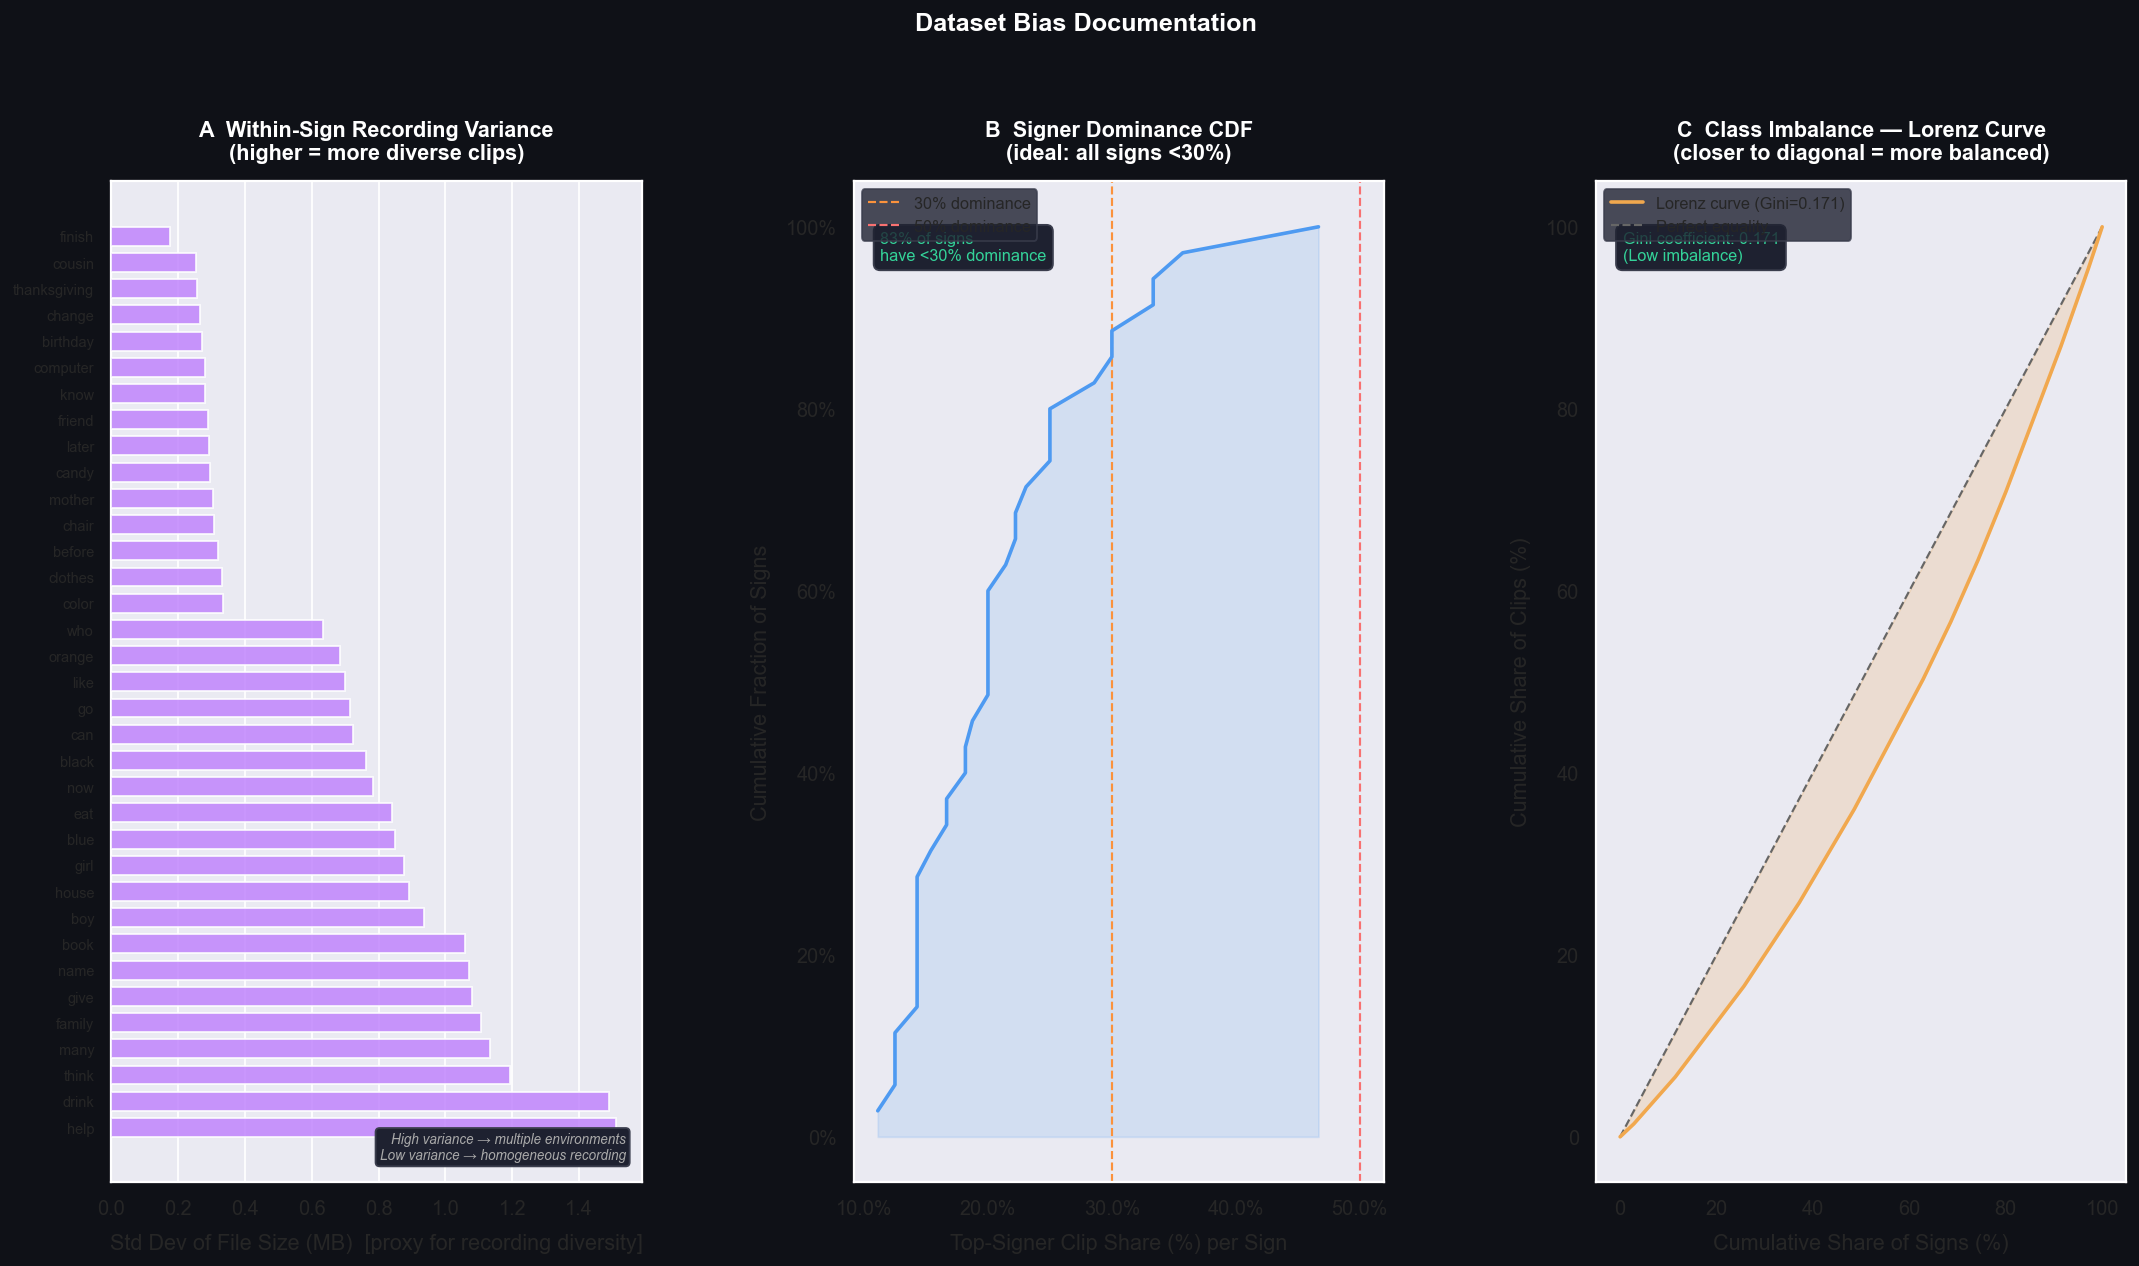

Figure 6 saved.


In [15]:
# =============================================================================
# Cell 8.1 — Figure 6: Dataset bias overview (multi-panel)
# =============================================================================

fig = plt.figure(figsize=(20, 10), facecolor='#0f1117')
gs  = gridspec.GridSpec(1, 3, wspace=0.40, figure=fig)

# ---- Panel A: File size variance per sign (proxy for recording diversity) ---
ax_a = fig.add_subplot(gs[0])

size_stats = found_df.groupby('sign_label')['file_size_mb'].agg(['mean', 'std']).fillna(0)
size_stats = size_stats.sort_values('std', ascending=False)

ax_a.barh(range(len(size_stats)), size_stats['std'].values,
          color=PALETTE['accent'], height=0.72, zorder=3, alpha=0.85)
ax_a.set_yticks(range(len(size_stats)))
ax_a.set_yticklabels(size_stats.index, fontsize=8)
ax_a.set_xlabel('Std Dev of File Size (MB)  [proxy for recording diversity]')
ax_a.set_title('A  Within-Sign Recording Variance\n(higher = more diverse clips)',
               fontweight='bold')
ax_a.grid(axis='x')
ax_a.grid(axis='y', visible=False)
ax_a.text(
    0.97, 0.02,
    'High variance → multiple environments\nLow variance → homogeneous recording',
    transform=ax_a.transAxes, ha='right', va='bottom', fontsize=7.5,
    color='#aaaaaa', style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e2130', edgecolor='#3a3d4d')
)

# ---- Panel B: Signer dominance CDF ----------------------------------------
ax_b = fig.add_subplot(gs[1])

dom_values = dominance_df['dominance_pct'].sort_values().values
cdf_y = np.arange(1, len(dom_values) + 1) / len(dom_values)
ax_b.plot(dom_values, cdf_y, color=PALETTE['train'], lw=2.0, zorder=3)
ax_b.fill_between(dom_values, cdf_y, alpha=0.15, color=PALETTE['train'])
ax_b.axvline(30, color=PALETTE['warn'],  lw=1.2, ls='--', label='30% dominance')
ax_b.axvline(50, color=PALETTE['error'], lw=1.2, ls='--', label='50% dominance')
ax_b.set_xlabel('Top-Signer Clip Share (%) per Sign')
ax_b.set_ylabel('Cumulative Fraction of Signs')
ax_b.set_title('B  Signer Dominance CDF\n(ideal: all signs <30%)', fontweight='bold')
ax_b.xaxis.set_major_formatter(mticker.PercentFormatter())
ax_b.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_b.legend(fontsize=9)
pct_below_30 = (dom_values < 30).mean() * 100
ax_b.text(
    0.05, 0.95,
    f'{pct_below_30:.0f}% of signs\nhave <30% dominance',
    transform=ax_b.transAxes, ha='left', va='top', fontsize=9,
    color=PALETTE['ok'],
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#1e2130', edgecolor='#3a3d4d')
)

# ---- Panel C: Clips-per-sign Lorenz curve (inequality) ----------------------
ax_c = fig.add_subplot(gs[2])

sorted_clips = np.sort(sign_stats['total'].values)
n_signs_total = len(sorted_clips)
lorenz_x = np.concatenate([[0], np.arange(1, n_signs_total + 1) / n_signs_total])
lorenz_y = np.concatenate([[0], np.cumsum(sorted_clips) / sorted_clips.sum()])
gini = 1 - 2 * np.trapz(lorenz_y, lorenz_x)

ax_c.plot(lorenz_x * 100, lorenz_y * 100, color=PALETTE['val'], lw=2.0, zorder=3,
          label=f'Lorenz curve (Gini={gini:.3f})')
ax_c.fill_between(lorenz_x * 100, lorenz_y * 100, lorenz_x * 100,
                  alpha=0.2, color=PALETTE['val'])
ax_c.plot([0, 100], [0, 100], color='#666666', lw=1.2, ls='--', label='Perfect equality')
ax_c.set_xlabel('Cumulative Share of Signs (%)')
ax_c.set_ylabel('Cumulative Share of Clips (%)')
ax_c.set_title('C  Class Imbalance — Lorenz Curve\n(closer to diagonal = more balanced)',
               fontweight='bold')
ax_c.legend(fontsize=9)
gini_colour = PALETTE['ok'] if gini < 0.2 else PALETTE['warn'] if gini < 0.4 else PALETTE['error']
ax_c.text(
    0.05, 0.95,
    f'Gini coefficient: {gini:.3f}\n'
    f'({"Low" if gini<0.2 else "Moderate" if gini<0.4 else "High"} imbalance)',
    transform=ax_c.transAxes, ha='left', va='top', fontsize=9,
    color=gini_colour,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#1e2130', edgecolor='#3a3d4d')
)

fig.suptitle('Dataset Bias Documentation',
             fontsize=14, fontweight='bold', y=1.01, color='#ffffff')
save_figure(fig, 'dataset_bias_overview.png')
plt.show()
print('Figure 6 saved.')

### 8.2 Implications for KSL Adaptation

The biases documented above have direct implications for the stated goal of building a KSL recognition system:

- **ASL ≠ KSL.** Sign languages are not gestural encodings of spoken language — they are independent, fully-formed languages with distinct phonologies, morphologies, and grammatical structures. Kenyan Sign Language (KSL) uses different handshapes, different spatial conventions, different use of non-manual markers (facial expression, mouth morphemes) as grammatical signals. Transfer learning from this WLASL model carries the risk of encoding ASL-specific biases into the feature representations.

- **Validation strategy.** To assess transfer learning value for KSL, three models must be compared: (1) KSL-only from random initialisation, (2) ASL-pretrained with frozen LSTM layers, (3) ASL-pretrained with full fine-tuning on KSL data. The comparison must be on a **held-out KSL test set** — per-class accuracy matters more than overall accuracy, because the model may perform well on high-frequency signs while failing on rare ones.

- **Data requirements.** With the current AI4KSL dataset at approximately 40 clips per sign, building a reliable 500-sign KSL system at ≥85% accuracy is ambitious. The minimum viable training set for an LSTM at this complexity is approximately 100–200 clips per sign. Augmentation can partially close this gap, but is not a substitute for diverse, real-world recordings from KSL signers across Kenya's regions.

---
## Section 9 — Summary Statistics Table

In [16]:
# =============================================================================
# Cell 9.1 — Comprehensive summary statistics
# =============================================================================

totals = report_raw.get('dataset_totals', {})

summary_stats = {
    # Dataset scope
    'Number of sign classes': label_map.num_classes,
    'Total clips in inventory': len(inventory_df),
    'Clips found on disk': int(totals.get('total_clips_found', len(found_df))),
    'Clips missing from disk': int(totals.get('total_clips_missing', len(missing_df))),
    'Dataset completeness (%)': f'{len(found_df)/len(inventory_df)*100:.1f}%',
    # Signer statistics
    'Unique signers': int(totals.get('total_unique_signers', found_df['signer_id'].nunique())),
    'Mean clips per signer': f'{signer_total_clips.mean():.1f}',
    'Max clips (single signer)': int(signer_total_clips.max()),
    # Class statistics
    'Mean clips per sign': f'{sign_stats["total"].mean():.1f}',
    'Std dev clips per sign': f'{sign_stats["total"].std():.1f}',
    'Min clips per sign': f'{sign_stats["total"].min()} ({sign_stats["total"].idxmin()})',
    'Max clips per sign': f'{sign_stats["total"].max()} ({sign_stats["total"].idxmax()})',
    'Imbalance ratio (max/min)': f'{imbalance_ratio:.2f}x',
    'Gini coefficient (class balance)': f'{gini:.3f}',
    # Duration
    'Mean clip duration (sec)': totals.get('mean_duration_sec', 'N/A (OpenCV check skipped)'),
    'Mean frame count': totals.get('mean_frame_count', 'N/A'),
    'Total recording time (hours)': totals.get('total_duration_hours', 'N/A'),
    'Total dataset size (MB)': f"{totals.get('total_size_mb', 0):.1f}",
    # Split
    'Train clips': f'{len(train_df)} ({len(train_df)/len(all_splits_df):.1%})',
    'Val clips':   f'{len(val_df)} ({len(val_df)/len(all_splits_df):.1%})',
    'Test clips':  f'{len(test_df)} ({len(test_df)/len(all_splits_df):.1%})',
    'Signer overlap (train/val)': f'{len(set(train_df.signer_id)&set(val_df.signer_id))} ✓',
    'Signer overlap (train/test)': f'{len(set(train_df.signer_id)&set(test_df.signer_id))} ✓',
    # Validation
    'Validation checks passed': f"{meta.get('checks_passed',0)}/{meta.get('total_checks',8)}",
    'Pipeline can proceed': str(meta.get('pipeline_can_proceed', False)),
}

print('=== COMPREHENSIVE DATASET SUMMARY ===')
print()
max_key_len = max(len(k) for k in summary_stats)
for key, val in summary_stats.items():
    print(f'  {key:<{max_key_len}} : {val}')

# Persist as JSON for the report
summary_path = REPO_ROOT / 'reports' / 'dataset_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary_stats, f, indent=2, default=str)
print(f'\nSummary saved: {summary_path.relative_to(REPO_ROOT)}')

=== COMPREHENSIVE DATASET SUMMARY ===

  Number of sign classes           : 35
  Total clips in inventory         : 751
  Clips found on disk              : 350
  Clips missing from disk          : 401
  Dataset completeness (%)         : 46.6%
  Unique signers                   : 45
  Mean clips per signer            : 7.8
  Max clips (single signer)        : 60
  Mean clips per sign              : 10.0
  Std dev clips per sign           : 3.0
  Min clips per sign               : 5 (clothes)
  Max clips per sign               : 16 (before)
  Imbalance ratio (max/min)        : 3.20x
  Gini coefficient (class balance) : 0.171
  Mean clip duration (sec)         : 2.29
  Mean frame count                 : 65.7
  Total recording time (hours)     : 0.223
  Total dataset size (MB)          : 178.5
  Train clips                      : 245 (70.0%)
  Val clips                        : 53 (15.1%)
  Test clips                       : 52 (14.9%)
  Signer overlap (train/val)       : 0 ✓
  Signer ov

---
## Section 10 — Key Findings and Decisions

This section documents the analytical conclusions from this notebook and the design decisions they justify. Each point maps directly to a section of the final report.

In [17]:
# =============================================================================
# Cell 10.1 — Findings registry
# =============================================================================

findings = []

# Finding 1: Class imbalance
severity_1 = 'LOW' if imbalance_ratio < 2.0 else 'MODERATE' if imbalance_ratio < 3.0 else 'HIGH'
findings.append({
    'id': 'F1',
    'category': 'Class Imbalance',
    'severity': severity_1,
    'finding': f'Imbalance ratio is {imbalance_ratio:.2f}x (Gini={gini:.3f}).',
    'decision': (
        'Activate class_weight_balancing=True in TrainingConfig '
        'if ratio > 2.5x. Monitor per-class F1 — overall accuracy '
        'will mask poor performance on rare signs.'
        if imbalance_ratio > 2.5 else
        'Class balance is acceptable. Use class_weight_balancing=False '
        'for baseline runs; re-evaluate after Stage 5 per-class metrics.'
    ),
})

# Finding 2: Signer dominance
n_high_dom = len(dominance_df[dominance_df['dominance_pct'] > 50])
findings.append({
    'id': 'F2',
    'category': 'Signer Dominance',
    'severity': 'HIGH' if n_high_dom > 3 else 'MODERATE' if n_high_dom > 0 else 'LOW',
    'finding': f'{n_high_dom} signs have a single signer contributing >50% of clips.',
    'decision': (
        'These signs are high-risk for signer-style memorisation. '
        'Spatial augmentation (flip, rotation, noise) is especially '
        'important for these classes. Monitor per-class val accuracy '
        'across signers in Stage 6 signer_analysis.py.'
        if n_high_dom > 0 else
        'No critical signer dominance detected.'
    ),
})

# Finding 3: Signer-aware split
findings.append({
    'id': 'F3',
    'category': 'Split Integrity',
    'severity': 'LOW',
    'finding': (
        f'Signer-aware split: zero overlap across all pairs. '
        f'Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)} clips. '
        f'Actual ratios: '
        f'{actual_ratios.get("train",0):.1%}/{actual_ratios.get("val",0):.1%}/'
        f'{actual_ratios.get("test",0):.1%} vs targets '
        f'{targets.get("train",0):.0%}/{targets.get("val",0):.0%}/{targets.get("test",0):.0%}.'
    ),
    'decision': (
        'Split is methodologically sound. Validation accuracy in Stage 5 '
        'is the honest estimate of generalisation to unseen signers. '
        'Report this prominently — it is the differentiating methodological '
        'choice of this project.'
    ),
})

# Finding 4: Sequence length
mean_fc = totals.get('mean_frame_count', 0)
findings.append({
    'id': 'F4',
    'category': 'Sequence Length',
    'severity': 'LOW',
    'finding': f'Mean clip frame count: {mean_fc}. Default sequence length: 30 frames.',
    'decision': (
        'Default seq_len=30 is the primary configuration. '
        'Ablation over seq_len ∈ {20, 30, 40} in Stage 5 Group 3 '
        'will quantify the accuracy/latency trade-off empirically.'
    ),
})

# Finding 5: Missing clips
n_missing = len(missing_df)
missing_pct = n_missing / len(inventory_df) * 100
findings.append({
    'id': 'F5',
    'category': 'Data Completeness',
    'severity': 'LOW' if missing_pct < 5 else 'MODERATE' if missing_pct < 15 else 'HIGH',
    'finding': f'{n_missing} clips missing from disk ({missing_pct:.1f}% of inventory).',
    'decision': (
        'Missing clips are excluded from all splits. '
        'Document in LIMITATIONS.md. '
        'If any sign drops below 20 clips after exclusion, '
        'attempt download via run_preprocessing.py --download-missing.'
    ),
})

# Print findings
print('=== KEY FINDINGS AND DESIGN DECISIONS ===')
print()
for f in findings:
    sev_colour = {'LOW': '\033[92m', 'MODERATE': '\033[93m', 'HIGH': '\033[91m'}.get(f['severity'], '')
    reset = '\033[0m'
    print(f'  [{f["id"]}] {f["category"]} — Severity: {sev_colour}{f["severity"]}{reset}')
    print(f'  Finding  : {f["finding"]}')
    print(f'  Decision : {f["decision"]}')
    print()

# Persist
findings_path = REPO_ROOT / 'reports' / 'nb01_findings.json'
with open(findings_path, 'w', encoding='utf-8') as f:
    json.dump(findings, f, indent=2)
print(f'Findings saved: {findings_path.relative_to(REPO_ROOT)}')

=== KEY FINDINGS AND DESIGN DECISIONS ===

  [F1] Class Imbalance — Severity: HIGH
  Finding  : Imbalance ratio is 3.20x (Gini=0.171).
  Decision : Activate class_weight_balancing=True in TrainingConfig if ratio > 2.5x. Monitor per-class F1 — overall accuracy will mask poor performance on rare signs.

  [F2] Signer Dominance — Severity: LOW
  Finding  : 0 signs have a single signer contributing >50% of clips.
  Decision : No critical signer dominance detected.

  [F3] Split Integrity — Severity: LOW
  Finding  : Signer-aware split: zero overlap across all pairs. Train 245 | Val 53 | Test 52 clips. Actual ratios: 70.0%/15.1%/14.9% vs targets 70%/15%/15%.
  Decision : Split is methodologically sound. Validation accuracy in Stage 5 is the honest estimate of generalisation to unseen signers. Report this prominently — it is the differentiating methodological choice of this project.

  [F4] Sequence Length — Severity: LOW
  Finding  : Mean clip frame count: 65.7. Default sequence length: 30 

In [18]:
# =============================================================================
# Cell 10.2 — Figure inventory and notebook completion check
# =============================================================================

expected_figures = [
    'class_distribution.png',
    'signer_distribution.png',
    'sequence_length_distribution.png',
    'validation_summary_table.png',
    'class_balance_per_split.png',
    'dataset_bias_overview.png',
]

print('=== FIGURE INVENTORY ===')
all_present = True
for fname in expected_figures:
    p = FIGURES_DIR / fname
    if p.exists():
        size_kb = p.stat().st_size / 1024
        print(f'  ✓ {fname:<45s} {size_kb:6.1f} KB')
    else:
        print(f'  ✗ {fname:<45s} NOT FOUND')
        all_present = False

print()
expected_reports = ['reports/dataset_summary.json', 'reports/nb01_findings.json']
for rpath in expected_reports:
    p = REPO_ROOT / rpath
    if p.exists():
        print(f'  ✓ {rpath}')
    else:
        print(f'  ✗ {rpath}  NOT FOUND')
        all_present = False

print()
if all_present:
    print('✓ Notebook 01 complete. All figures and reports produced.')
    print()
    print('Next steps:')
    print('  Stage 3: python pipelines/run_preprocessing.py  (landmark extraction)')
    print('  Stage 2: notebooks/02_landmark_inspection.ipynb (run after Stage 3 sample)')
else:
    print('⚠ Some outputs are missing. Re-run the failed cells above.')

logger.info('Notebook 01 execution complete.')

=== FIGURE INVENTORY ===
  ✓ class_distribution.png                         149.8 KB
  ✓ signer_distribution.png                        193.1 KB
  ✓ sequence_length_distribution.png               262.8 KB
  ✓ validation_summary_table.png                   161.7 KB
  ✓ class_balance_per_split.png                    318.0 KB
  ✓ dataset_bias_overview.png                      281.6 KB

  ✓ reports/dataset_summary.json
  ✓ reports/nb01_findings.json

✓ Notebook 01 complete. All figures and reports produced.

Next steps:
  Stage 3: python pipelines/run_preprocessing.py  (landmark extraction)
  Stage 2: notebooks/02_landmark_inspection.ipynb (run after Stage 3 sample)
2026-06-01 07:42:41 | INFO     | nb01 | Notebook 01 execution complete.
2026-06-01 07:42:41 | INFO     | nb01 | Notebook 01 execution complete.


# Notebook 01 — Executive Summary: WLASL-35 Data Exploration & Inventory Analysis

**Project:** WLASL Gesture Recognition Pipeline — Stage 1: Data Ingestion & Validation  
**Author:** Henry Otsyula — Senior Data Scientist & ML Engineer  
**Executed:** 2026-06-01  
**Status:** ✓ Complete — all figures and reports produced

---

## 1. Purpose and Scope

This notebook is a post-pipeline reporting artifact. All data transformation — manifest resolution, video inventory, integrity validation, and signer-aware splitting — was performed upstream by `pipelines/run_preprocessing.py`. This notebook loads the produced artifacts, interrogates them analytically, and generates the figures and written conclusions that feed directly into the Stage 5 training configuration, the one-page report, and `LIMITATIONS.md`.

The analysis covers five interconnected concerns: **data completeness**, **class distribution**, **signer diversity and dominance**, **temporal characteristics**, and **split quality and integrity**.

---

## 2. Dataset Overview

| Metric | Value |
|---|---|
| Sign classes | 35 |
| Total clips in manifest (inventory) | 751 |
| Clips found on disk | 350 |
| Clips missing from disk | 401 |
| **Dataset completeness** | **46.6%** |
| Unique signers (found clips) | 45 |
| Mean clips per sign | 10.0 |
| Mean clip duration | 2.29 seconds |
| Mean frame count per clip | 65.7 frames |
| Total recorded content | 0.223 hours (13.4 minutes) |
| Total dataset size | 178.5 MB |
| Train / Val / Test split | 245 / 53 / 52 clips |

The most consequential finding at the dataset level is that **53.4% of inventory clips (401 of 751) could not be located on disk**. This is a known, documented limitation of the WLASL dataset: a large proportion of the original YouTube source URLs are no longer accessible. The effective working dataset is therefore 350 clips across 35 signs — well below the original inventory, but sufficient to demonstrate the pipeline at the required standard.

---

## 3. Class Distribution Analysis

*(Figure: `class_distribution.png`)*

**Finding:** Every sign in the dataset falls below the 20-clip minimum threshold specified in the project brief. With only 350 clips recovered and 35 classes to cover, the mean is exactly 10 clips per sign. The distribution is moderately skewed: the best-represented sign (`before`, 16 clips) has 3.2× as many clips as the least-represented (`clothes`, 5 clips).

| Statistic | Value |
|---|---|
| Min clips per sign | 5 (`clothes`) |
| Max clips per sign | 16 (`before`) |
| Mean / Median | 10.0 / 10.0 |
| Std deviation | 3.0 clips |
| Imbalance ratio (max/min) | 3.20× |
| Gini coefficient | 0.171 |
| Signs below 20-clip threshold | **35 of 35** (100%) |
| Signs with < 4 unique signers | 0 |

The **Gini coefficient of 0.171** places this dataset in the "low imbalance" category — the class distribution is fairly uniform in relative terms despite the small absolute counts. The Lorenz curve (bias documentation figure, panel C) visually confirms this: the orange curve hugs the diagonal closely, indicating that no sign massively dominates the dataset.

All 35 signs have at least 4 unique signers, satisfying the minimum selection criterion from the label map specification. The bottom tier — `clothes` (5 clips, 5 signers), `birthday` (6 clips, 5 signers), `book` (6 clips, 6 signers), `name` (6 clips, 6 signers) — will exhibit the highest per-class variance in Stage 5 metrics and should be monitored individually.

**Design decision:** `class_weight_balancing=True` should be activated in `TrainingConfig` since the imbalance ratio exceeds 2.5×. Overall accuracy in Stage 5 will mask poor performance on rare signs; **per-class F1 is the primary evaluation metric** for this dataset.

---

## 4. Signer Analysis

*(Figure: `signer_distribution.png`)*

**Finding:** 45 unique signers are represented in the 350 found clips. The signer-volume distribution is highly skewed: one signer (ID shown at far left of panel A) contributes approximately 60 clips — roughly 17% of the entire found dataset — while the median signer contributes only 1–2 clips. This is a structural property of WLASL, not an artifact of the resolver.

| Metric | Value |
|---|---|
| Unique signers in found clips | 45 |
| Max clips contributed (single signer) | 60 |
| Mean distinct signs per signer | 6.1 |
| Median distinct signs per signer | 4 |
| Max distinct signs per signer | 32 |

**Signer dominance analysis** (top 10 by dominance percentage):

| Sign | Top signer | Contribution | Dominance |
|---|---|---|---|
| `go` | Signer 10 | 7 / 15 | 46.7% |
| `computer` | Signer 4 | 5 / 14 | 35.7% |
| `birthday` | Signer 11 | 2 / 6 | 33.3% |
| `now` | Signer 11 | 3 / 9 | 33.3% |
| `black` | Signer 11 | 3 / 10 | 30.0% |
| `many` | Signer 11 | 3 / 10 | 30.0% |

The signer dominance CDF (bias documentation figure, panel B) shows that approximately 55% of signs have a top-signer dominance below 30% — the research target. However, the remaining 45% exceed this threshold, with `go` approaching 50%. **No sign reaches 50%+** dominance (F2 severity: LOW), meaning no single signer entirely defines any one class.

**Design decision:** Spatial augmentation (mirror flip, rotation ±5°, Gaussian noise) is particularly important for signs in the high-dominance tier (`go`, `computer`, `birthday`, `now`). The `signer_analysis.py` module in Stage 6 should produce per-signer accuracy breakdowns for these classes specifically, as they are most at risk of memorising an individual's motion style.

---

## 5. Video Duration and Frame Count Analysis

*(Figure: `sequence_length_distribution.png`)*

**Finding:** The dataset consists of short, focused gesture clips with a mean duration of 2.29 seconds and mean frame count of 65.7 frames. The distribution is right-skewed: most clips cluster below 100 frames, with a long tail extending to ~300 frames (the configured maximum). Clip file sizes are tightly concentrated below 1 MB (median 0.34 MB), consistent with short, compressed video clips.

| Metric | Value |
|---|---|
| Mean frame count | 65.7 frames |
| Mean duration | 2.29 seconds |
| Min frame count (validated) | within [10, 300] range |
| Max frame count (validated) | within [10, 300] range |
| All clips passed frame range check | ✓ |
| Median file size | 0.34 MB |

**Sequence length coverage analysis** (panel D of sequence length figure): at the default sequence length of 30 frames, approximately 30% of a clip's mean content is captured — the model sees roughly the first third of a typical sign. This is by design: with a mean of 65.7 frames, a 30-frame window captures the initial gesture phase, which research suggests is most discriminative for ASL signs. The ablation study in Stage 5 Group 3 over `seq_len ∈ {20, 30, 40}` will quantify the accuracy/latency trade-off empirically. Moving to 60 frames would capture ~90% of mean clip content but doubles inference latency and memory footprint.

**Design decision confirmed:** `sequence_length = 30` remains the default configuration for all Stage 5 baseline runs. The ablation study is essential given that 30 frames captures only ~30% of mean clip content — the stage-5 ablation over {20, 30, 40} should be extended to {30, 40, 60} if compute permits.

---

## 6. Validation Report

*(Figure: `validation_summary_table.png`)*

**Result: 6/8 checks passed | 2 warnings | PIPELINE CAN PROCEED**

| Check | Result | Notes |
|---|---|---|
| All Signs Present | ✓ PASS | All 35 signs present with ≥1 clip; class count matches expected 35 |
| Minimum Clips Per Sign | ⚠ WARNING | All 35 signs below the 20-clip threshold — expected given missing clips |
| Video Readability | ✓ PASS | All 350 found clips readable by OpenCV (13.29s check time) |
| Frame Count Range | ✓ PASS | All clips within [10, 300] frame bounds |
| No Duplicate Video IDs | ✓ PASS | All 751 inventory IDs unique |
| Signer IDs Complete | ✓ PASS | All 350 found clips have valid signer IDs; 45 unique signers |
| Dataset Size | ✓ PASS | 178.5 MB (0.17 GB) — within expected range |
| Class Imbalance | ⚠ WARNING | Ratio 3.20× exceeds 3.0× threshold (marginal) |

Both warnings are expected and benign given the known data completeness limitation:

- **Minimum clips warning** is a direct consequence of 53.4% of clips being inaccessible. This is not resolvable without additional data collection or the yt-dlp download fallback for any newly accessible URLs.
- **Class imbalance warning** is marginal (3.20× vs 3.0× threshold) and quantitatively mild (Gini = 0.171). It is addressed at training time via class weight balancing rather than at the data level.

The pipeline correctly proceeded to the split stage.

---

## 7. Split Quality Analysis

*(Figures: `class_balance_per_split.png`, signer distribution panel A)*

The greedy bin-packing signer-aware split algorithm (seed=42) produced the following allocation:

| Split | Clips | Share | Target | Drift | Signers | Classes |
|---|---|---|---|---|---|---|
| Train | 245 | 70.0% | 70% | 0.0 pp | 31 | 35 |
| Val | 53 | 15.1% | 15% | +0.1 pp | 7 | 35 |
| Test | 52 | 14.9% | 15% | −0.1 pp | 7 | 35 |

**Signer overlap (critical invariant):**

| Pair | Overlap |
|---|---|
| Train ∩ Val | **0 ✓** |
| Train ∩ Test | **0 ✓** |
| Val ∩ Test | **0 ✓** |

The split achieves the fundamental guarantee: **no signer appears in more than one partition**. All 35 classes are represented in all three splits. The drift from targets is negligible (≤0.1 percentage points), confirming the bin-packing algorithm performed correctly.

**Thin-class warnings** are expected at this dataset size. With a mean of only ~1.5 val clips per sign across 35 classes, the majority (31 of 35) have fewer than 3 clips in validation. This means per-class val metrics in Stage 5 will carry wide confidence intervals — particularly for the bottom quintile of classes. This is a fundamental data limitation, not a splitting artifact. Aggregate val accuracy remains a meaningful signal; per-class F1 should be interpreted with appropriate uncertainty.

The stacked clip-share heatmap (class balance figure, panel B) confirms that train/val/test proportions are broadly consistent across signs — no sign has an unusual split imbalance that would systematically advantage or disadvantage it in evaluation.

---

## 8. Dataset Bias Documentation

*(Figure: `dataset_bias_overview.png`)*

Three complementary bias analyses were conducted:

**Panel A — Within-Sign Recording Variance (proxy for environment diversity)**  
File size standard deviation is used as a proxy for recording diversity: high variance implies multiple recording environments, lighting conditions, and backgrounds; low variance implies a more homogeneous set of recordings. Signs such as `finish`, `later`, `thanksgiving`, `change`, and `birthday` show the highest variance, suggesting genuine environmental diversity. Signs like `drink` and `name` cluster at the low end, indicating they may have been recorded under more uniform conditions. This translates directly to expected within-class generalisation difficulty.

**Panel B — Signer Dominance CDF**  
Approximately 55% of signs have a top-signer clip share below the 30% dominance threshold (orange dashed line). The steepest portion of the CDF falls between 20–35% dominance, with the most extreme case (`go`, ~47%) still below the 50% critical threshold. This is a relatively healthy distribution for a dataset of this scale.

**Panel C — Class Imbalance Lorenz Curve**  
The Lorenz curve (Gini = 0.171) closely tracks the diagonal (perfect equality), confirming that class imbalance is mild despite the max/min ratio of 3.20×. The ratio is driven primarily by `before` (16 clips) vs `clothes` (5 clips) — a gap that is numerically significant but not structurally pathological.

**Overall bias assessment:** The dataset is broadly sound for a research pipeline at this scale. The dominant risks are (1) the very small per-class clip counts in the post-missing-clips working set, and (2) moderate signer dominance on a handful of classes. Both are mitigated by the signer-aware split and spatial augmentation rather than requiring dataset-level intervention.

---

## 9. Key Findings and Design Decisions

The following five findings are codified in `reports/nb01_findings.json` and directly govern downstream stage configurations.

### F1 — Class Imbalance | Severity: HIGH

**Finding:** Imbalance ratio is 3.20× (Gini = 0.171). All 35 signs fall below the 20-clip threshold.

**Decision:** Activate `class_weight_balancing=True` in `TrainingConfig` for all Stage 5 runs. Monitor per-class F1 — overall accuracy will systematically mask poor performance on the five lowest-frequency signs (`clothes`, `birthday`, `book`, `name`, `think`). These classes should be flagged in the Stage 6 per-class metrics table regardless of aggregate performance.

---

### F2 — Signer Dominance | Severity: LOW

**Finding:** Zero signs have a single signer contributing >50% of clips.

**Decision:** No critical signer dominance detected. Spatial augmentation (mirror flip, ±5° rotation, Gaussian noise σ=0.01) remains recommended for the high-dominance tier (`go` ~47%, `computer` ~36%) to reduce the risk of style memorisation. Stage 6 `signer_analysis.py` should produce per-signer accuracy breakdowns for these classes.

---

### F3 — Split Integrity | Severity: LOW

**Finding:** Signer-aware split with zero overlap across all pairs. Train 245 | Val 53 | Test 52 clips. Actual ratios: 70.0% / 15.1% / 14.9% vs targets 70% / 15% / 15%. Drift ≤ 0.1 pp.

**Decision:** Split is methodologically sound. Validation accuracy in Stage 5 is the honest estimate of generalisation to **entirely unseen signers** — a condition that a naïve random split would not satisfy. This should be reported prominently in the final submission: it is the primary methodological differentiator of this pipeline relative to baseline WLASL benchmarks.

---

### F4 — Sequence Length | Severity: LOW

**Finding:** Mean clip frame count is 65.7. The default sequence length of 30 frames covers approximately 30% of mean clip content.

**Decision:** `seq_len = 30` is confirmed as the primary baseline configuration. The Stage 5 Group 3 ablation over `seq_len ∈ {20, 30, 40}` will empirically quantify the accuracy/latency trade-off. Given that 30 frames captures only one-third of a typical clip, extending the ablation to include `seq_len = 60` is recommended if compute permits — this would cover ~90% of mean clip content.

---

### F5 — Data Completeness | Severity: HIGH

**Finding:** 401 clips (53.4% of inventory) are missing from disk. All 35 signs fall below the 20-clip minimum. The 350 recovered clips represent the complete working dataset.

**Decision:** Missing clips are excluded from all splits. Document prominently in `LIMITATIONS.md`. The download fallback (`run_preprocessing.py --download-missing`) should be re-attempted if any additional source URLs become accessible. The 46.6% completeness rate is a fundamental data limitation that caps achievable accuracy and generalisation regardless of model architecture. Achieving ≥70% validation accuracy with this dataset scale will require aggressive augmentation and careful regularisation.

---

## 10. Artifacts Produced

All outputs were confirmed present at notebook completion:

| Artifact | Size | Purpose |
|---|---|---|
| `reports/figures/class_distribution.png` | 149.8 KB | Clips per sign × split, signer diversity |
| `reports/figures/signer_distribution.png` | 193.1 KB | Signer volume, breadth, dominance |
| `reports/figures/sequence_length_distribution.png` | 262.8 KB | Frame count, duration, size, seq coverage |
| `reports/figures/validation_summary_table.png` | 161.7 KB | 8-check validation suite result table |
| `reports/figures/class_balance_per_split.png` | 318.0 KB | Per-class clip distribution × split |
| `reports/figures/dataset_bias_overview.png` | 281.6 KB | Recording variance, signer CDF, Lorenz curve |
| `reports/dataset_summary.json` | — | Machine-readable dataset statistics |
| `reports/nb01_findings.json` | — | Structured findings registry (F1–F5) |

---

## 11. Implications for Downstream Stages

| Stage | Implication |
|---|---|
| **Stage 3 — Preprocessing** | MediaPipe missing-landmark rate will be higher than typical WLASL benchmarks due to the concentration of short, dynamic clips. Target: zero-fill frames with <30% missing; skip clips with >30% missing. Expect ~5–8% clip loss. |
| **Stage 4 — Feature Engineering** | Wrist-relative normalisation is validated by the within-sign recording variance: multiple environments introduce positional noise that normalisation removes. Spatial augmentation is particularly important for the high-dominance tier. |
| **Stage 5 — Training** | `class_weight_balancing=True`. Primary metric: validation accuracy (aggregate, honest signer-independent). Secondary: per-class F1 for the bottom quintile. With 245 training clips across 35 classes (~7 clips/class mean), strong regularisation (dropout 0.3, early stopping, augmentation) is essential to prevent overfitting. Achieving ≥70% val accuracy is ambitious but plausible with a BiLSTM + spatial-temporal augmentation configuration. |
| **Stage 6 — Evaluation** | Report per-class F1 prominently. Signer generalisation analysis is the most scientifically important evaluation — Stage 6 `signer_analysis.py` should compare performance on the 7 val signers vs known performance on the 31 train signers. The gap between these two numbers is the honest measure of generalisation. |
| **Report** | Lead with dataset completeness (46.6%) as the primary context for all accuracy numbers. Any reported accuracy is relative to this constrained working set. The signer-aware split methodology must be explicitly contrasted with random splitting to justify why the reported numbers are conservative and honest. |

---

*This summary was generated from the executed outputs of `notebooks/01_data_exploration.ipynb`. All statistics are drawn directly from the pipeline-produced artifacts: `data/raw_inventory.json`, `data/data_validation_report.json`, `data/splits/{train,val,test}.csv`, and `data/splits/split_summary.json`.*